# Overview:

**Aim:** The aim of this project is to develop an end-to-end fraud detection system using the IEEE-CIS Fraud Detection dataset. The project involves exploratory data analysis, feature engineering, machine learning model development, and deployment to identify potentially fraudulent transactions in real time.

**Use Cases:** This solution can be used by financial institutions, payment processors, and e-commerce platforms to automatically detect suspicious transactions, reduce financial losses, and improve customer security. 

# Exploratory Data Analysis (EDA)

The dataset used here is provided by Vesta Corportation, a company that provides e-commerce payment solutions. 

Kaggle Competition: https://www.kaggle.com/competitions/ieee-fraud-detection/overview

Data Overview provided in the competition:

**Transaction Table:**  
TransactionDT: timedelta from a given reference datetime (not an actual timestamp)  
TransactionAMT: transaction payment amount in USD  
ProductCD: product code, the product for each transaction  
card1 - card6: payment card information, such as card type, card category, issue bank, country, etc.  
addr: address  
dist: distance  
P_ and (R__) emaildomain: purchaser and recipient email domain  
C1-C14: counting, such as how many addresses are found to be associated with the payment card, etc. The actual meaning is masked.  
D1-D15: timedelta, such as days between previous transaction, etc.  
M1-M9: match, such as names on card and address, etc.  
Vxxx: Vesta engineered rich features, including ranking, counting, and other entity relations.  
Categorical Features: ProductCD, card1 - card6, addr1, addr2, P_emaildomain, R_emaildomain, M1 - M9   

**Identity Table:**  
Variables in this table are identity information – network connection information (IP, ISP, Proxy, etc) and digital signature (UA/browser/os/version, etc) associated with transactions. They're collected by Vesta’s fraud protection system and digital security partners. (The field names are masked and pairwise dictionary will not be provided for privacy protection and contract agreement)  

Categorical Features: DeviceType, DeviceInfo, id_12 - id_38  

In this notebook, we will only explore the dataset in order to understand the data, features and correlations between features better.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We have two files - transaction and identity.
# These two are joined by transaction ID.
# Not all transactions have corresponding identity information.

train_transaction = pd.read_csv("data/train_transaction.csv")
train_identity = pd.read_csv("data/train_identity.csv")

In [3]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
train_transaction.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


In [8]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [9]:
train_identity.info()

<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id_17          139369 non-null  float64


In [3]:
# Merge the datasets
train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

In [4]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


**Dataset Summary:**
- Total number of transactions: 590540
- Total number transaction features: 394
- Total number of identity features: 41
- Total number of features after merging: 435

## Missing Value Analysis

In [37]:
train_transaction[train_transaction.columns[train_transaction.isnull().any()]].isnull().sum().sort_values(ascending=False)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
          ...  
V302         12
V303         12
V304         12
V305         12
V306         12
Length: 374, dtype: int64

In [38]:
train_identity[train_identity.columns[train_identity.isnull().any()]].isnull().sum().sort_values(ascending=False)   

id_24         139486
id_25         139101
id_07         139078
id_08         139078
id_21         139074
id_26         139070
id_22         139064
id_27         139064
id_23         139064
id_18          99120
id_03          77909
id_04          77909
id_33          70944
id_10          69307
id_09          69307
id_30          66668
id_32          66647
id_34          66428
id_14          64189
DeviceInfo     25567
id_13          16913
id_16          14893
id_05           7368
id_06           7368
id_20           4972
id_19           4915
id_17           4864
id_31           3951
DeviceType      3423
id_02           3361
id_29           3255
id_11           3255
id_28           3255
id_15           3248
id_36           3248
id_35           3248
id_38           3248
id_37           3248
dtype: int64

In [39]:
transaction_missing = train_transaction.isnull().mean().sort_values(ascending=False) * 100
print("Percentage of missing transactions:\n", transaction_missing)

Percentage of missing transactions:
 dist2             93.628374
D7                93.409930
D13               89.509263
D14               89.469469
D12               89.041047
                    ...    
ProductCD          0.000000
TransactionAmt     0.000000
TransactionDT      0.000000
isFraud            0.000000
TransactionID      0.000000
Length: 394, dtype: float64


In [40]:
identity_missing = train_identity.isnull().mean().sort_values(ascending=False) * 100
print("Percentage of missing identities:\n", identity_missing)

Percentage of missing identities:
 id_24            96.708798
id_25            96.441868
id_07            96.425922
id_08            96.425922
id_21            96.423149
id_26            96.420375
id_23            96.416215
id_27            96.416215
id_22            96.416215
id_18            68.722137
id_04            54.016071
id_03            54.016071
id_33            49.187079
id_10            48.052110
id_09            48.052110
id_30            46.222432
id_32            46.207872
id_34            46.056034
id_14            44.503685
DeviceInfo       17.726179
id_13            11.726165
id_16            10.325654
id_06             5.108401
id_05             5.108401
id_20             3.447200
id_19             3.407681
id_17             3.372321
id_31             2.739318
DeviceType        2.373243
id_02             2.330257
id_28             2.256765
id_29             2.256765
id_11             2.256765
id_38             2.251912
id_35             2.251912
id_36             2.

In [41]:
results = []

for col in train.columns:

    missing_pct = train[col].isnull().mean()

    if missing_pct > 0.9:

        temp = train[col].isnull().astype(int)

        fraud_missing = train.loc[temp == 1, 'isFraud'].mean()   # Fraud when the column is missing
        fraud_present = train.loc[temp == 0, 'isFraud'].mean()   # Fraud when the column is present

        diff = abs(fraud_missing - fraud_present)

        results.append([
            col,
            missing_pct,
            fraud_missing,
            fraud_present,
            diff
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        'column',
        'missing_pct',
        'fraud_missing',
        'fraud_present',
        'difference'
    ]
)

results_df.sort_values(
    'difference',
    ascending=False
)

,column,missing_pct,fraud_missing,fraud_present,difference
1,D7,0.934099,0.026962,0.148778,0.121816
0,dist2,0.936284,0.030623,0.099158,0.068534
4,id_18,0.923607,0.031036,0.082792,0.051756
8,id_24,0.991962,0.034587,0.084685,0.050098
3,id_08,0.991271,0.034570,0.082638,0.048068
2,id_07,0.991271,0.034570,0.082638,0.048068
5,id_21,0.991264,0.034571,0.082574,0.048003
6,id_22,0.991247,0.034571,0.082414,0.047843
7,id_23,0.991247,0.034571,0.082414,0.047843
11,id_27,0.991247,0.034571,0.082414,0.047843


- This table shows us the fraud percentage when a particular value is present v/s missing.
- For instance, when D7 is missing, the fraud percentage is just 2%, whereas when it's present the fraud percentage is 14.8%, which is a huge difference.
- Sometimes just a value being present or absent could affect the analysis.

In [42]:
cols = results_df['column']
train[cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dist2   37627 non-null  float64
 1   D7      38917 non-null  float64
 2   id_07   5155 non-null   float64
 3   id_08   5155 non-null   float64
 4   id_18   45113 non-null  float64
 5   id_21   5159 non-null   float64
 6   id_22   5169 non-null   float64
 7   id_23   5169 non-null   str    
 8   id_24   4747 non-null   float64
 9   id_25   5132 non-null   float64
 10  id_26   5163 non-null   float64
 11  id_27   5169 non-null   str    
dtypes: float64(10), str(2)
memory usage: 54.1 MB


In [43]:
# Missing Indicator 

high_missing_cols = [
    col
    for col in train.columns
        if train[col].isnull().mean() > 0.90
]

for col in high_missing_cols:
    train[f'{col}_missing'] = (
        train[col].isnull().astype(int)
    )

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_25104\4209854071.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f'{col}_missing'] = (
C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_25104\4209854071.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f'{col}_missing'] = (
C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_25104\4209854071.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

In [44]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_07_missing,id_08_missing,id_18_missing,id_21_missing,id_22_missing,id_23_missing,id_24_missing,id_25_missing,id_26_missing,id_27_missing
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,1,1,1,1,1,1,1,1,1,1
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,1,1,1,1,1,1,1,1,1,1
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,1,1,1,1,1,1,1,1,1,1
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,1,1,1,1,1,1,1,1,1,1
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,1,1,1,1,1,1,1,1,1,1


- We have created missing indicators for columns with more than 90% of the data missing.
- These indicators will serve as new predictors for our model and can also be used visualisation.

In [45]:
missing_analysis = []

for col in high_missing_cols:
    indicator = f'{col}_missing'

    fraud_rate = (
        train.groupby(indicator)['isFraud']
        .mean()
    )

    missing_analysis.append({
        'column': col,
        'fraud_not_missing': fraud_rate.get(0, np.nan),
        'fraud_missing': fraud_rate.get(1, np.nan),
        'difference': fraud_rate.get(1, np.nan) - fraud_rate.get(0, np.nan)
    })

missing_analysis = pd.DataFrame(missing_analysis)
missing_analysis = missing_analysis.sort_values(
    'difference',
    ascending=False
)

missing_analysis

,column,fraud_not_missing,fraud_missing,difference
9,id_25,0.081255,0.034584,-0.046670
10,id_26,0.082316,0.034573,-0.047744
6,id_22,0.082414,0.034571,-0.047843
7,id_23,0.082414,0.034571,-0.047843
11,id_27,0.082414,0.034571,-0.047843
5,id_21,0.082574,0.034571,-0.048003
2,id_07,0.082638,0.034570,-0.048068
3,id_08,0.082638,0.034570,-0.048068
8,id_24,0.084685,0.034587,-0.050098
4,id_18,0.082792,0.031036,-0.051756


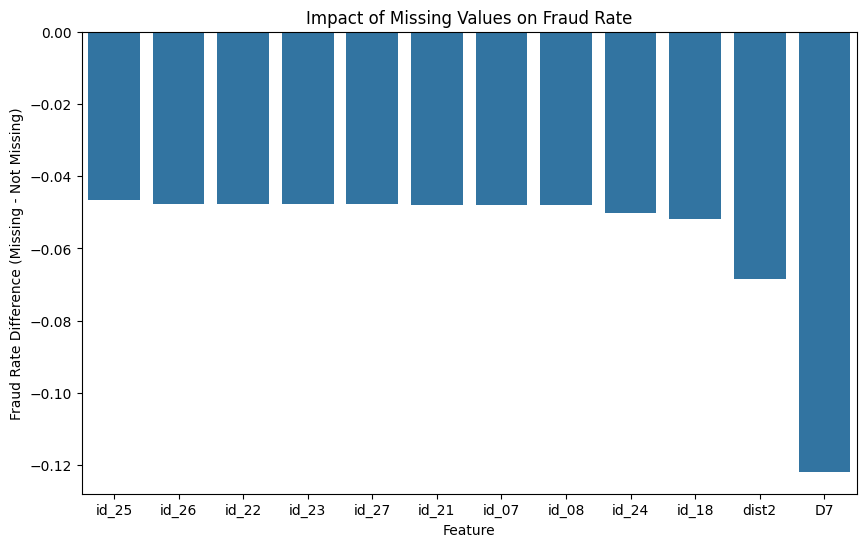

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=missing_analysis,
    x='column',
    y='difference'
)

plt.title('Impact of Missing Values on Fraud Rate')
plt.xlabel('Feature')
plt.ylabel('Fraud Rate Difference (Missing - Not Missing)')
plt.show()

Note: Missing indicators are created for columns with >90% missingness. For moderately missing columns (30–90%), missingness is captured implicitly by the model (tree-based models handle NaN natively via surrogate splits).


## Class Imbalance Analysis

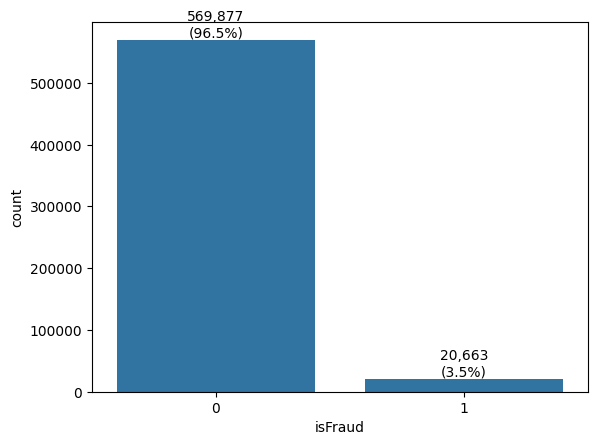

In [52]:
ax = sns.countplot(data=train, x='isFraud')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(train)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

In [18]:
train['isFraud'].value_counts(normalize=True)*100 

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

- Only 3.5% of the transactions are fraudulent.
- We'll have to handle this imbalance while training our models and also during evaluation by using the right metrics.

## Fraud Rate by Categorical Features

These are the categorical features provided by the Vesta team here: https://www.kaggle.com/competitions/ieee-fraud-detection/data.

**Transaction:**  
ProductCD  
card1 - card6  
addr1, addr2  
P_emaildomain  
R_emaildomain  
M1 - M9   

**Identity:**  
DeviceType  
DeviceInfo  
id_12 - id_38  

In [15]:
# Let's check the number of categories in each column

cat_cols = ['ProductCD', 'card1', 'card2', 'card3','card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'dist1', 'dist2',
        'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
        'DeviceType', 'DeviceInfo',]

for col in cat_cols:
    print(f'{col}: {train[col].nunique()}')

ProductCD: 5
card1: 13553
card2: 500
card3: 114
card4: 4
card5: 119
card6: 4
addr1: 332
addr2: 74
P_emaildomain: 59
R_emaildomain: 60
dist1: 2651
dist2: 1751
M1: 2
M2: 2
M3: 2
M4: 3
M5: 2
M6: 2
M7: 2
M8: 2
M9: 2
DeviceType: 2
DeviceInfo: 1786


### 1. ProductCD, DeviceType, card1-card6

Checking columns which have fewer categories for better understanding.

In [4]:
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType']

cat_cols_missing = train[cat_cols].isnull().mean().sort_values(ascending=False) * 100
print("Percentage of missing transactions:\n", cat_cols_missing)

Percentage of missing transactions:
 DeviceType    76.155722
card4          0.267044
card6          0.266028
ProductCD      0.000000
dtype: float64


In [5]:
train.fillna({'DeviceType': 'Missing', 'card4': 'Missing', 'card6': 'Missing'}, inplace=True)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing,NaN


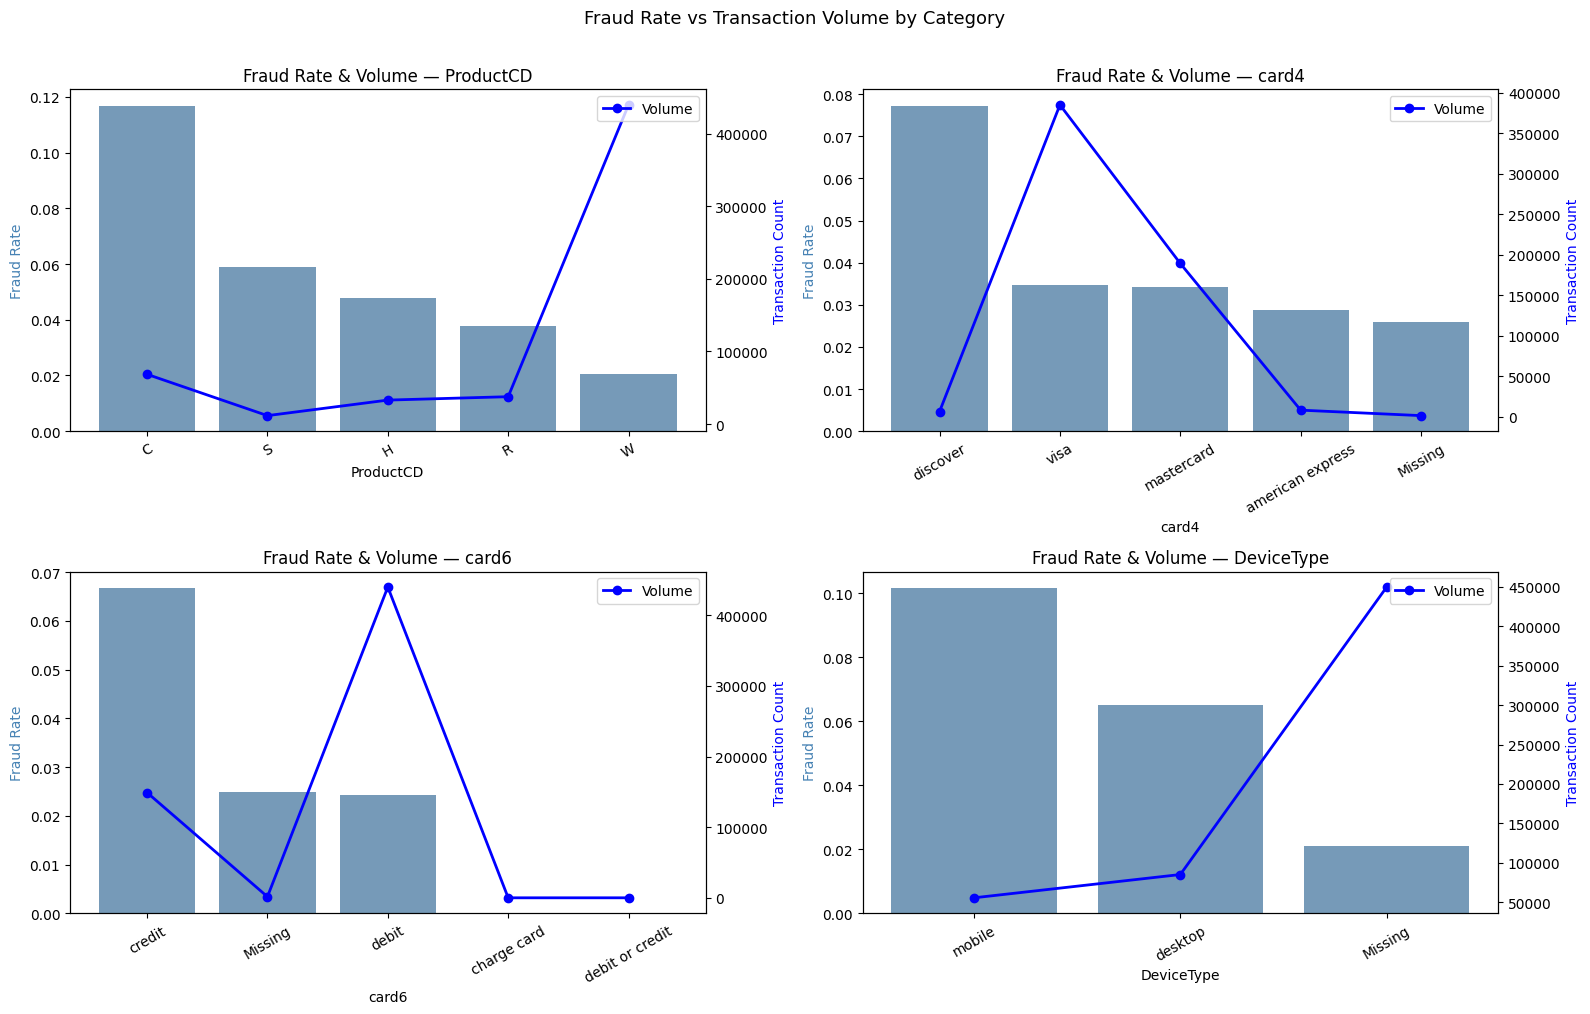

In [6]:
cols = ['ProductCD', 'card4', 'card6', 'DeviceType']  # low-cardinality first

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    stats = (
        train.groupby(col)['isFraud']
        .agg(['mean', 'count', 'sum'])
        .rename(columns={'mean': 'fraud_rate', 'count': 'total', 'sum': 'frauds'})
        .sort_values('fraud_rate', ascending=False)
        .reset_index()
    )

    ax1 = axes[i]
    ax2 = ax1.twinx()  # second y-axis for volume

    sns.barplot(data=stats, x=col, y='fraud_rate', ax=ax1, color='steelblue', alpha=0.8)
    ax2.plot(stats[col], stats['total'], color='blue', marker='o', linewidth=2, label='Volume')

    ax1.set_title(f'Fraud Rate & Volume — {col}')
    ax1.set_ylabel('Fraud Rate', color='steelblue')
    ax2.set_ylabel('Transaction Count', color='blue')
    ax1.tick_params(axis='x', rotation=30)
    ax2.legend(loc='upper right')

plt.suptitle('Fraud Rate vs Transaction Volume by Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Note: Here we are calculating the fraud rate by category.
# Eg. Mobile: 10% means → out of all mobile transactions, 10% are fraud
# It's saying "if a transaction is mobile, there's a 10% chance it's fraud."

ProductCD
- Category C has the highest fraud rate (~12%) but very low volume — so while it's a strong signal, it affects fewer transactions.
- W has the highest volume (most common product) but lowest fraud rate (~2%) — the bulk of transactions are relatively safe.
- S is interesting — second highest fraud rate (~6%) with very low volume. Worth flagging as a high-risk niche product type.

card4
- Discover has the highest fraud rate (~7.5%) despite very low volume — low volume + high fraud rate means this signal is noisy but directionally meaningful.
- Visa dominates volume and has a moderately high fraud rate (~7%) — because of its sheer volume, Visa transactions will make up the majority of actual fraud cases in absolute numbers even though the rate is similar to Discover.
- The key takeaway: don't confuse fraud rate with fraud volume — Visa's moderate rate × massive volume = most fraud cases.

card6 (Card Type)
- Credit cards have the highest fraud rate (~6.7%).
- Debit cards are second (~2.5%) with much higher volume.
- Charge card and debit-or-credit have near-zero entries — likely data quality issues or very rare card types, not meaningful signals.

DeviceType
- Mobile has ~10% fraud rate vs desktop's ~6% — mobile transactions are significantly riskier.
- Volume is roughly similar between the two, so both rates are statistically trustworthy.
- This is a clean, reliable signal — DeviceType will likely be a useful feature.

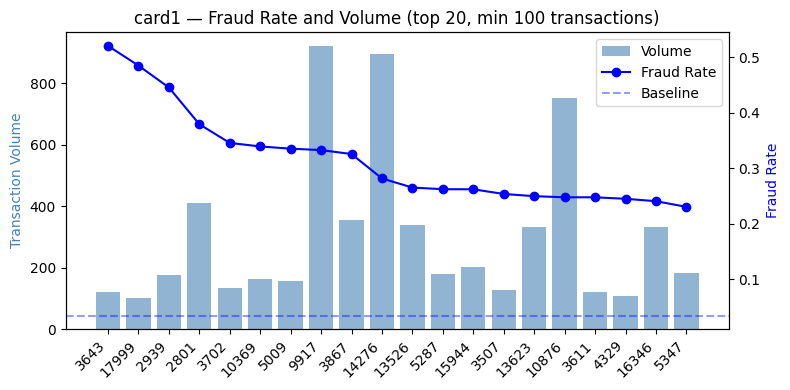

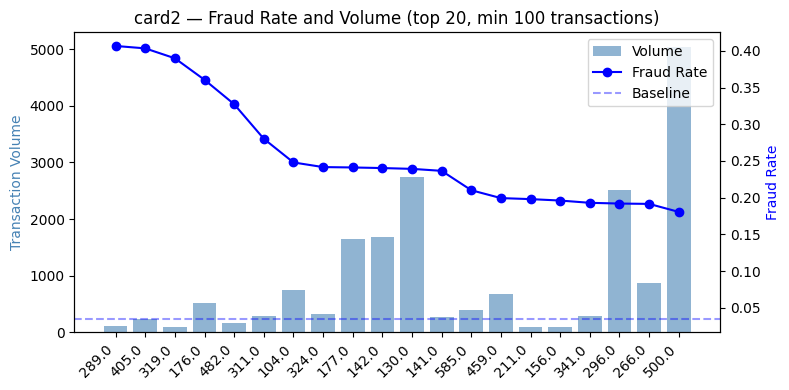

In [12]:
# cards 1 and 2
# card 1 and card 2 have extremely high cardinality - difficult to visualise. 
# They can be handled during feature engineering, mostly using target encoding.

cols = ['card1', 'card2']

for col in cols:
    stats = (
        train.groupby(col)['isFraud']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
    )
    stats = stats[stats['volume'] >= 100].sort_values('fraud_rate', ascending=False).head(20)

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax2 = ax1.twinx()

    x = range(len(stats))
    ax1.bar(x, stats['volume'], color='steelblue', alpha=0.6, label='Volume')
    ax2.plot(x, stats['fraud_rate'], color='blue', marker='o', linewidth=1.5, label='Fraud Rate')
    ax2.axhline(train['isFraud'].mean(), color='blue', linestyle='--', alpha=0.4, label='Baseline')

    ax1.set_xticks(x)
    ax1.set_xticklabels(stats.index.astype(str), rotation=45, ha='right')
    ax1.set_ylabel('Transaction Volume', color='steelblue')
    ax2.set_ylabel('Fraud Rate', color='blue')
    ax1.set_title(f'{col} — Fraud Rate and Volume (top 20, min 100 transactions)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.tight_layout()
    plt.show()

card 1
- All top categories have fraud rate above the baseline. 
- Card 3643 has the highest fraud rate of 52% with some meaningful volume too.
- Cards 9917 and 14276 have moderate fraud rate with high volumes.
- High fraud rate AND high volume = the most impactful compromised cards in absolute fraud case terms.
- Volume is irregular — doesn't correlate with fraud rate. Some high-fraud cards have low volume (targeted, quick use) and some have high volume (sustained fraud ring activity)

card 2
- card2=289 and card2=405 at ~40% fraud rate with 118 and 228 transactions.
- card2=500 has the largest volume (~4,000 transactions) with ~21% fraud rate — this is the most impactful entry: 4,000 transactions at 21% means ~840 fraud cases from a single card2 value.

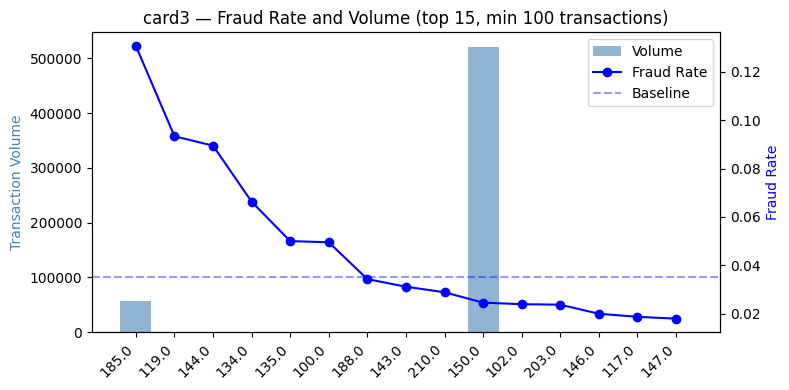

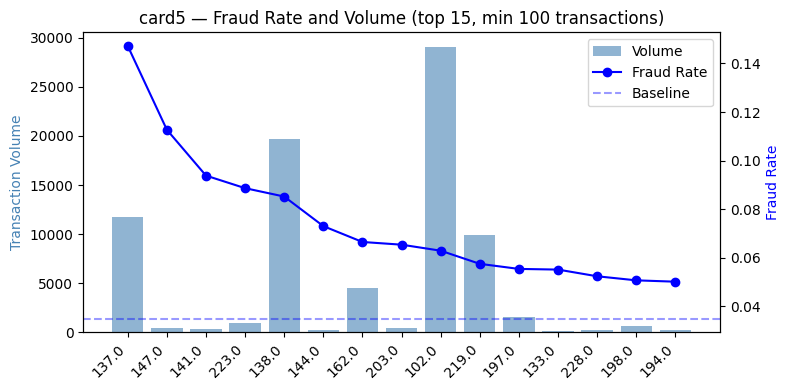

In [10]:
# cards 3 and 5
# We will only use the top 15 categories for visualisation, ones having at least 100 transactions.

cols = ['card3', 'card5']

for col in cols:
    stats = (
        train.groupby(col)['isFraud']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
    )
    stats = stats[stats['volume'] >= 100].sort_values('fraud_rate', ascending=False).head(15)

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax2 = ax1.twinx()

    x = range(len(stats))
    ax1.bar(x, stats['volume'], color='steelblue', alpha=0.6, label='Volume')
    ax2.plot(x, stats['fraud_rate'], color='blue', marker='o', linewidth=1.5, label='Fraud Rate')
    ax2.axhline(train['isFraud'].mean(), color='blue', linestyle='--', alpha=0.4, label='Baseline')

    ax1.set_xticks(x)
    ax1.set_xticklabels(stats.index.astype(str), rotation=45, ha='right')
    ax1.set_ylabel('Transaction Volume', color='steelblue')
    ax2.set_ylabel('Fraud Rate', color='blue')
    ax1.set_title(f'{col} — Fraud Rate and Volume (top 15, min 100 transactions)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.tight_layout()
    plt.show()

card 3
- card3=185: 13.1% fraud rate with 56,346 transactions — this is the high-risk category with substantial volume, nearly 4x the baseline.
- card3=150: dominates volume (521,287 transactions) at just 2.5% fraud — the safe dominant category.
- The remaining categories show a monotonically declining fraud rate.

card 5
- Values are nominal codes and not ordinal levels. Target encoding would be the best approach.
- Fraud rate is above the baseline for all categories.

### 2. DeviceInfo

In [56]:
print(train['DeviceInfo'].value_counts().head(30))

DeviceInfo
Windows                           47722
iOS Device                        19782
MacOS                             12573
Trident/7.0                        7440
rv:11.0                            1901
rv:57.0                             962
SM-J700M Build/MMB29K               549
SM-G610M Build/MMB29K               461
SM-G531H Build/LMY48B               410
rv:59.0                             362
SM-G935F Build/NRD90M               334
SM-G955U Build/NRD90M               328
SM-G532M Build/MMB29T               316
ALE-L23 Build/HuaweiALE-L23         312
SM-G950U Build/NRD90M               290
SM-G930V Build/NRD90M               274
rv:58.0                             269
rv:52.0                             256
SAMSUNG                             235
SM-G950F Build/NRD90M               225
Moto G (4) Build/NPJ25.93-14.7      219
SM-N950U Build/NMF26X               209
SM-A300H Build/LRX22G               203
hi6210sft Build/MRA58K              190
SM-J730GM Build/NRD90M       

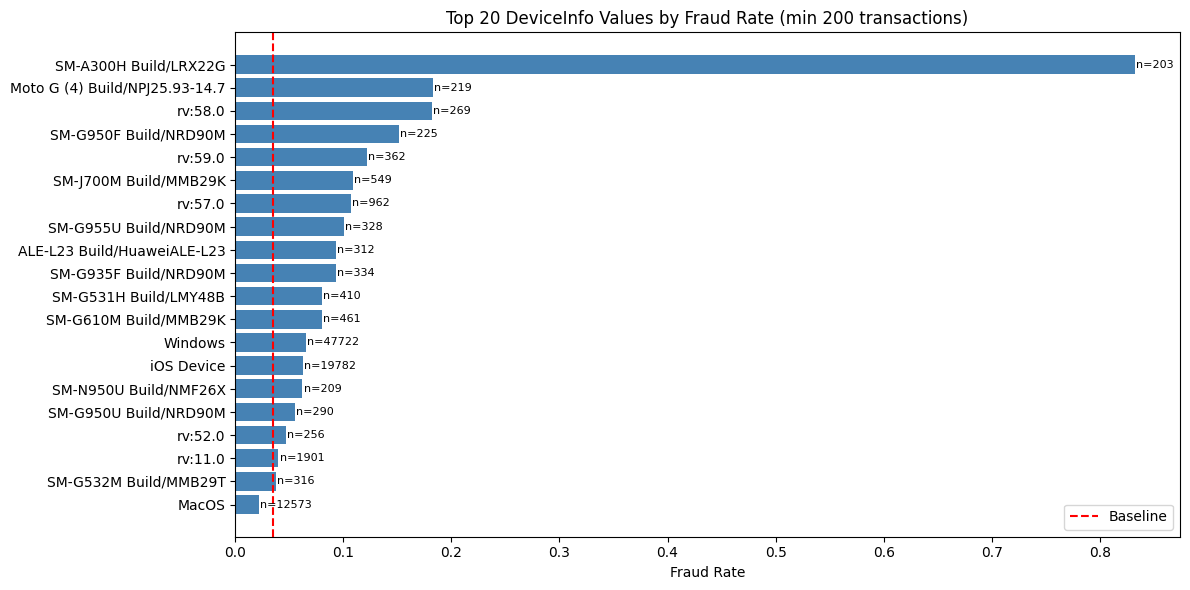

In [60]:
device_raw_stats = (
    train.groupby('DeviceInfo')['isFraud']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
)

# Filter min volume, sort by fraud rate
device_raw_top = (
    device_raw_stats[device_raw_stats['volume'] >= 200]
    .sort_values('fraud_rate', ascending=False)
    .head(20)
    .reset_index()
)

plt.figure(figsize=(12, 6))
bars = plt.barh(device_raw_top['DeviceInfo'], device_raw_top['fraud_rate'], 
                color='steelblue')
plt.axvline(train['isFraud'].mean(), color='red', linestyle='--', label='Baseline')

for bar, (_, row) in zip(bars, device_raw_top.iterrows()):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"n={int(row['volume'])}", va='center', fontsize=8)

plt.title('Top 20 DeviceInfo Values by Fraud Rate (min 200 transactions)')
plt.xlabel('Fraud Rate')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

- SM-A300H Build/LRX22G - Highest fraud rate at ~83% in 203 transactions.
- The next 3 are between 15 to 20%.
- Windows and iOS have a large number of transactions, 47K and 19K respectively. Fraud rate is much lower than other models.
- SM-G532M Build/MMB29T has very low fraud rate showing not all samsung models have a higher fraud rate. 

In [57]:
# We can cluster the devices into categories for a better understanding and visualisation

def categorise_device(device):
    if pd.isnull(device):
        return 'Missing'
    device = str(device).lower()
    
    if 'windows' in device:
        return 'Windows'
    if 'ios' in device or 'iphone' in device or 'ipad' in device:
        return 'iOS'
    if 'macos' in device or 'mac os' in device:
        return 'MacOS'
    if 'trident' in device or 'rv:11' in device:
        return 'IE/Trident'        # Internet Explorer
    if device.startswith('rv:'):
        return 'Firefox'           # rv:52+ are Firefox
    if 'sm-' in device or 'samsung' in device:
        return 'Samsung Android'
    if 'huawei' in device or 'ale-' in device or 'cam-' in device \
        or 'hi6' in device:
        return 'Huawei Android'
    if 'moto' in device:
        return 'Motorola Android'
    if 'lg-' in device:
        return 'LG Android'
    if 'android' in device:
        return 'Other Android'
    if 'linux' in device:
        return 'Linux'
    return 'Other'

train['DeviceInfo_grouped'] = train['DeviceInfo'].apply(categorise_device)
print(train['DeviceInfo_grouped'].value_counts())

DeviceInfo_grouped
Missing             471874
Windows              47775
iOS                  19783
MacOS                12573
Samsung Android      11940
IE/Trident            9341
Other                 6695
Motorola Android      2935
Huawei Android        2606
Firefox               2484
LG Android            2331
Linux                  121
Other Android           82
Name: count, dtype: int64


C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_25104\3466700428.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['DeviceInfo_grouped'] = train['DeviceInfo'].apply(categorise_device)


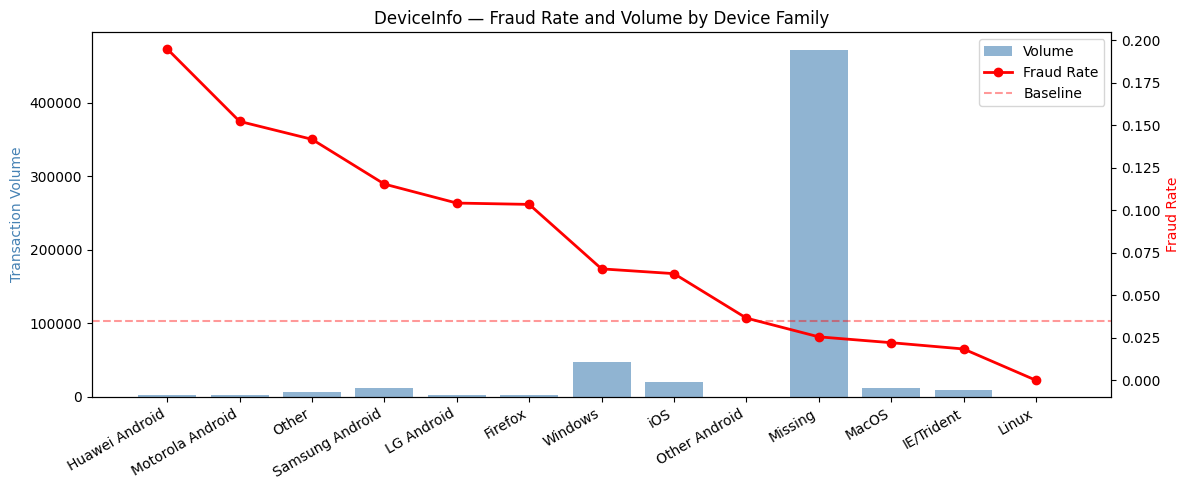

In [58]:
device_stats = (
    train.groupby('DeviceInfo_grouped')['isFraud']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
    .sort_values('fraud_rate', ascending=False)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = range(len(device_stats))

ax1.bar(x, device_stats['volume'], color='steelblue', alpha=0.6, label='Volume')
ax2.plot(x, device_stats['fraud_rate'], color='red', marker='o', 
         linewidth=2, label='Fraud Rate')
ax2.axhline(train['isFraud'].mean(), color='red', linestyle='--', 
            alpha=0.4, label='Baseline')

ax1.set_xticks(x)
ax1.set_xticklabels(device_stats['DeviceInfo_grouped'], rotation=30, ha='right')
ax1.set_ylabel('Transaction Volume', color='steelblue')
ax2.set_ylabel('Fraud Rate', color='red')
ax1.set_title('DeviceInfo — Fraud Rate and Volume by Device Family')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

- Huawei has the highest fraud rate with a low number of transactions, followed by Motorola, Others and Samsung. 
- There are a large volume of transactions with missing DeviceInfo, however the fraud rate is still below the baseline. This shows absence of the value might link to low risk of frauds.
- We will use these same categories while feature engineering.

### 3. M1-M9

In [8]:
m_cols = ['M1','M2','M3','M4','M5','M6','M7','M8','M9']

for col in m_cols:
    print(f"{train[col].value_counts()}")

M1
T    319415
F        25
Name: count, dtype: int64
M2
T    285468
F     33972
Name: count, dtype: int64
M3
T    251731
F     67709
Name: count, dtype: int64
M4
M0    196405
M2     59865
M1     52826
Name: count, dtype: int64
M5
F    132491
T    107567
Name: count, dtype: int64
M6
F    227856
T    193324
Name: count, dtype: int64
M7
F    211374
T     32901
Name: count, dtype: int64
M8
F    155251
T     89037
Name: count, dtype: int64
M9
T    205656
F     38632
Name: count, dtype: int64


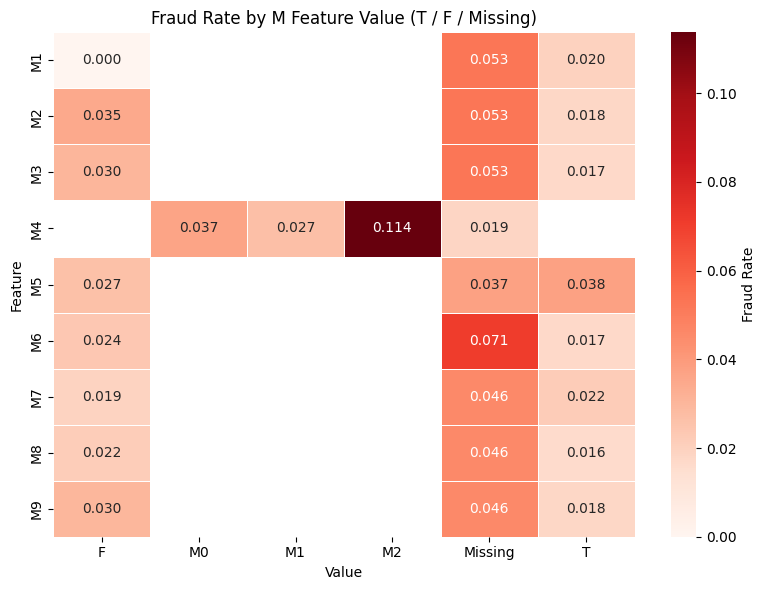

In [36]:
# M features have these values - T/F/M0/M1/M2/NaN

m_cols = ['M1','M2','M3','M4','M5','M6','M7','M8','M9']

m_fraud = {}
for col in m_cols:
    m_fraud[col] = train.groupby(train[col].fillna('Missing'))['isFraud'].mean()

m_fraud_df = pd.DataFrame(m_fraud).T  # rows = M features, cols = T/F/Missing

plt.figure(figsize=(8, 6))
sns.heatmap(
    m_fraud_df,
    annot=True,
    fmt='.3f',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Fraud Rate'}
)
plt.title('Fraud Rate by M Feature Value (T / F / Missing)')
plt.xlabel('Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Note: M4 uses a different encoding (M0/M1/M2 confidence levels) vs T/F for other M features. The blank cells mean that combination doesn't exist — not zero fraud rate.

M6:
- The pattern: Missing (7.1%) >> F (2.4%) > T (1.7%)
- This tells you that when M6 can't even be evaluated, fraud risk is nearly 3x higher than a failed match, and 4x higher than a successful match. The absence of a match result (T/F) is a stronger red flag than a mismatch.
- As missingness itself is a fraud signal here —  we fill NaN with 'Missing' as an explicit category rather than leaving it as NaN.

M4:
- M4=M2 (strong match) = 11.4% fraud rate — the darkest cell.
- There is strong signal from this column.

Fraudsters often bypass verification steps entirely, which is why Missing outranks even an explicit mismatch (F).

### 4. id_12-id_38

In [46]:
id_cols = []

for i in range(12, 39):
    id_cols.append('id_' + str(i))

for col in id_cols:
    print(f'{col}: {train[col].nunique()}')

id_12: 2
id_13: 54
id_14: 25
id_15: 3
id_16: 2
id_17: 104
id_18: 18
id_19: 522
id_20: 394
id_21: 490
id_22: 25
id_23: 3
id_24: 12
id_25: 341
id_26: 95
id_27: 2
id_28: 2
id_29: 2
id_30: 75
id_31: 130
id_32: 4
id_33: 260
id_34: 4
id_35: 2
id_36: 2
id_37: 2
id_38: 2


In [48]:
# Same pattern we used for M and D features
id_missing_analysis = []

for col in id_cols:
    indicator = train[col].isnull().astype(int)
    fraud_missing = train.loc[indicator == 1, 'isFraud'].mean()
    fraud_present = train.loc[indicator == 0, 'isFraud'].mean()

    id_missing_analysis.append({
        'feature': col,
        'missing_pct': train[col].isnull().mean() * 100,
        'fraud_rate_missing': fraud_missing,
        'fraud_rate_present': fraud_present,
        'difference': fraud_missing - fraud_present
    })

id_missing_df = (
    pd.DataFrame(id_missing_analysis)
    .sort_values('difference', ascending=False)
)

print(id_missing_df)

   feature  missing_pct  fraud_rate_missing  fraud_rate_present  difference
7    id_32    86.861855            0.033555            0.044480   -0.010925
8    id_34    86.824771            0.033503            0.044791   -0.011289
4    id_27    99.124699            0.034571            0.082414   -0.047843
3    id_23    99.124699            0.034571            0.082414   -0.047843
2    id_16    78.098012            0.022791            0.078491   -0.055700
0    id_12    75.576083            0.020939            0.078470   -0.057532
6    id_29    76.127273            0.021009            0.079573   -0.058563
5    id_28    76.127273            0.021009            0.079573   -0.058563
1    id_15    76.126088            0.021001            0.079597   -0.058596
9    id_35    76.126088            0.021001            0.079597   -0.058596
10   id_36    76.126088            0.021001            0.079597   -0.058596
11   id_37    76.126088            0.021001            0.079597   -0.058596
12   id_38  

In [13]:
# Low cardinality columns only

id_cols = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_32', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

train[id_cols] = train[id_cols].fillna('Missing')

for col in id_cols:
    print('\n')
    print(train.groupby(col)['isFraud'].mean())



id_12
Found       0.059836
Missing     0.020939
NotFound    0.081683
Name: isFraud, dtype: float64


id_15
Found      0.105097
Missing    0.021001
New        0.049244
Unknown    0.091885
Name: isFraud, dtype: float64


id_16
Found       0.107231
Missing     0.022791
NotFound    0.048242
Name: isFraud, dtype: float64


id_23
IP_PROXY:ANONYMOUS      0.137255
IP_PROXY:HIDDEN         0.055829
IP_PROXY:TRANSPARENT    0.070221
Missing                 0.034571
Name: isFraud, dtype: float64


id_27
Found       0.082638
Missing     0.034571
NotFound    0.000000
Name: isFraud, dtype: float64


id_28
Found      0.102752
Missing    0.021009
New        0.052281
Name: isFraud, dtype: float64


id_29
Found       0.104463
Missing     0.021009
NotFound    0.051338
Name: isFraud, dtype: float64


id_32
0.0        0.500000
16.0       0.222222
24.0       0.033917
32.0       0.066727
Missing    0.033555
Name: isFraud, dtype: float64


id_34
Missing            0.033503
match_status:-1    0.000000
match_st

**Analysis:**

- Missing fraud rate is ~2.1% almost universally — id_15, id_16, id_28, id_29, id_35, id_36, id_37, id_38 all show exactly 0.021. This is not a coincidence.
- The missingness here is structural (no identity record collected), not informative in the same way as D or M feature missingness.
- Missing values occur because no identity record exists for that transaction at all — the entire identity table row is absent. Fraud rate when missing is BELOW baseline (~2.1% vs 3.5% overall).

id_23:
- Anonymous   13.7%   ← actively hiding identity
- Transparent  7.0%   ← routed but visible  
- Hidden       5.6%   ← somewhere between
- Missing      3.5%   ← no proxy = normal transaction
- Anonymous proxy is 4x riskier than no proxy.

id_32:
- This is a numeric feature representing screen colour depth in bits. 24-bit and 32-bit are standard modern displays.
- 0-bit = 50% fraud rate — a screen colour depth of 0 means no screen, i.e. a bot or automated script with no real browser rendering.
- 16-bit = 22% — old or emulated display, suspicious.
- 24/32-bit = normal — real human devices, low fraud.

id_12: NotFound is riskier 

id_16/id_28/id_29: Found is riskier.

id_35, id_36, id_38: Consistent F > T pattern

id_37: Anomaly — T > F

### 5. P_emaildomain, R_emaildomain

In [48]:
print(f"Number of categories in P_emaildomain: {train['P_emaildomain'].nunique()}")
print(f"Number of categories in R_emaildomain: {train['R_emaildomain'].nunique()}")

Number of categories in P_emaildomain: 59
Number of categories in R_emaildomain: 60


It's better to check the fraud rates of domains that have at least 100 transactions, this can remove all the domains which are rarely used.  

In [49]:
p_email_stats = (
    train.groupby('P_emaildomain')['isFraud']
    .agg(['count','sum','mean'])
)

p_email_stats = p_email_stats[
    p_email_stats['count'] >= 100
]

p_email_stats.sort_values(
    'mean',
    ascending=False
).head(15)

,count,sum,mean
P_emaildomain,,,
mail.com,559,106,0.189624
outlook.es,438,57,0.130137
aim.com,315,40,0.126984
outlook.com,5096,482,0.094584
hotmail.es,305,20,0.065574
live.com.mx,749,41,0.054740
hotmail.com,45250,2396,0.052950
gmail.com,228355,9943,0.043542
yahoo.fr,143,5,0.034965


In [50]:
r_email_stats = (
    train.groupby('R_emaildomain')['isFraud']
    .agg(['count','sum','mean'])
)

r_email_stats = r_email_stats[
    r_email_stats['count'] >= 100
]

r_email_stats.sort_values(
    'mean',
    ascending=False
).head(15)

,count,sum,mean
R_emaildomain,,,
mail.com,122,46,0.377049
outlook.com,2507,414,0.165138
outlook.es,433,57,0.131640
icloud.com,1398,180,0.128755
gmail.com,57147,6811,0.119184
hotmail.com,27509,2140,0.077793
hotmail.es,292,20,0.068493
live.com.mx,754,44,0.058355
yahoo.com,11842,610,0.051512


C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_25104\1590009686.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_25104\1590009686.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


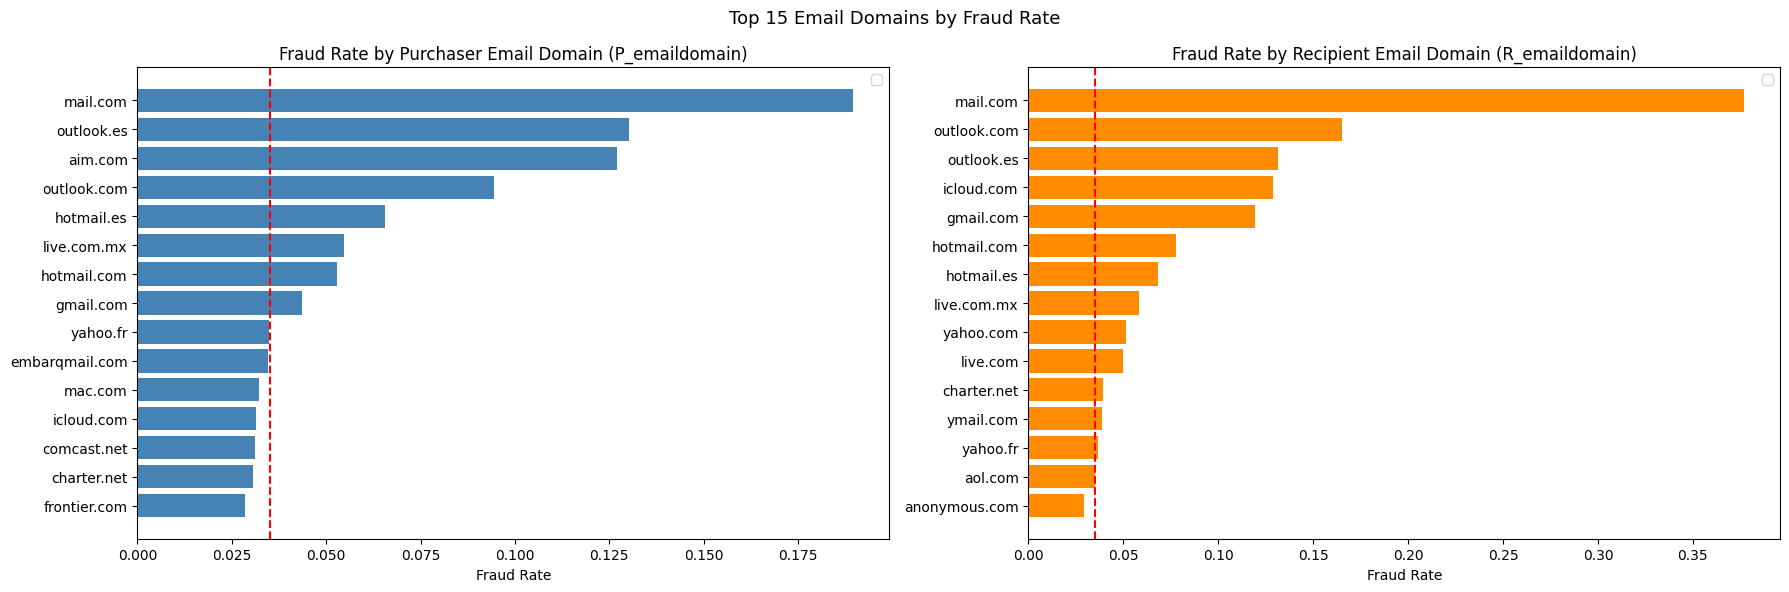

In [51]:
# Side by side comparison of P vs R email domains
# Find domains that appear in both tables for direct comparison

p_top = p_email_stats.sort_values('mean', ascending=False).head(15).reset_index()
r_top = r_email_stats.sort_values('mean', ascending=False).head(15).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# P_emaildomain
bars = axes[0].barh(p_top['P_emaildomain'], p_top['mean'], color='steelblue')
axes[0].set_title('Fraud Rate by Purchaser Email Domain (P_emaildomain)')
axes[0].set_xlabel('Fraud Rate')
axes[0].legend()
axes[0].invert_yaxis()

# R_emaildomain
bars = axes[1].barh(r_top['R_emaildomain'], r_top['mean'], color='darkorange')
axes[1].set_title('Fraud Rate by Recipient Email Domain (R_emaildomain)')
axes[1].set_xlabel('Fraud Rate')
axes[1].legend()
axes[1].invert_yaxis()

axes[0].axvline(train['isFraud'].mean(), color='red', linestyle='--', label='Baseline')
axes[1].axvline(train['isFraud'].mean(), color='red', linestyle='--', label='Baseline')

plt.suptitle('Top 15 Email Domains by Fraud Rate', fontsize=13)
plt.tight_layout()
plt.show()

- mail.com, outlook.es and outlook.com have high fraud rates in both cases, purchaser and recipient.
- These are also higher than the baseline fraud rate.
- Some of the emails can be grouped together during feature engineering - Like gmail, google.com, etc. 

### 6. addr1, addr2

In [5]:
cols = ['addr1', 'addr2']

for col in cols:
    print('\n')
    print(train.groupby(col)['isFraud'].mean())



addr1
100.0    0.000000
101.0    0.000000
102.0    0.000000
104.0    0.000000
105.0    0.000000
           ...   
530.0    0.000000
531.0    0.000000
535.0    0.000000
536.0    0.161812
540.0    0.000000
Name: isFraud, Length: 332, dtype: float64


addr2
10.0     1.0
13.0     0.0
14.0     0.0
15.0     0.0
16.0     0.0
        ... 
97.0     0.0
98.0     0.0
100.0    0.0
101.0    0.0
102.0    0.0
Name: isFraud, Length: 74, dtype: float64


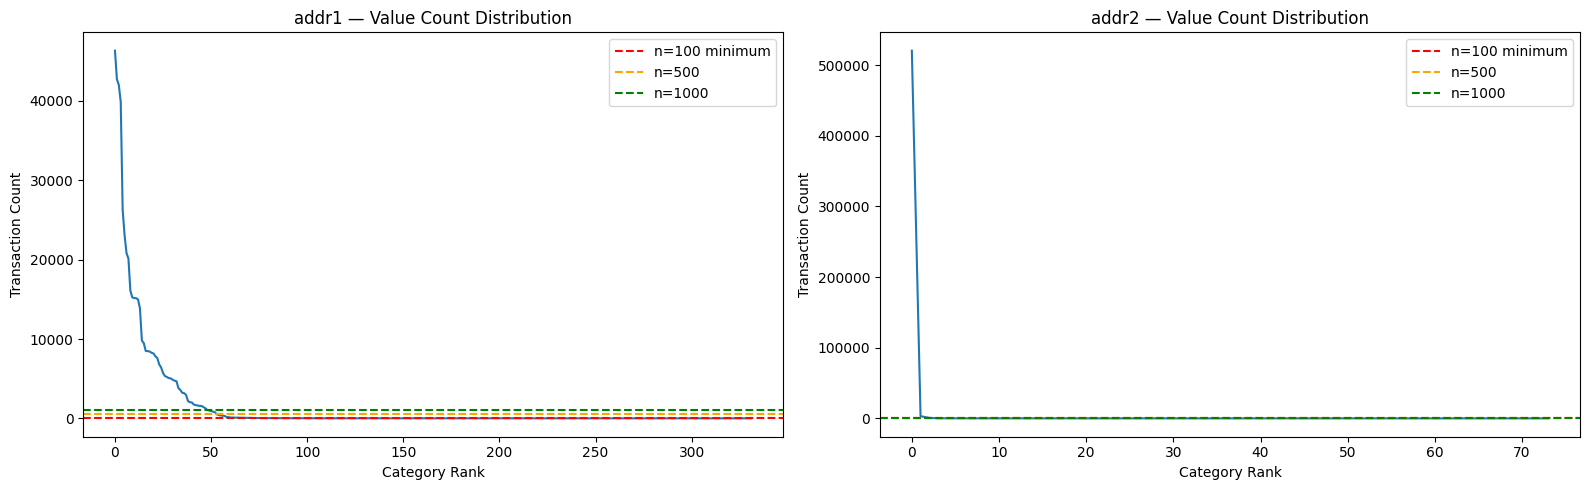

In [28]:
# Plot value count distributions for both
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['addr1', 'addr2']):
    counts = train[col].value_counts()
    ax.plot(range(len(counts)), counts.values)
    ax.axhline(100, color='red', linestyle='--', label='n=100 minimum')
    ax.axhline(500, color='orange', linestyle='--', label='n=500')
    ax.axhline(1000, color='green', linestyle='--', label='n=1000')
    ax.set_title(f'{col} — Value Count Distribution')
    ax.set_xlabel('Category Rank')
    ax.set_ylabel('Transaction Count')
    ax.legend()

plt.tight_layout()
plt.show()

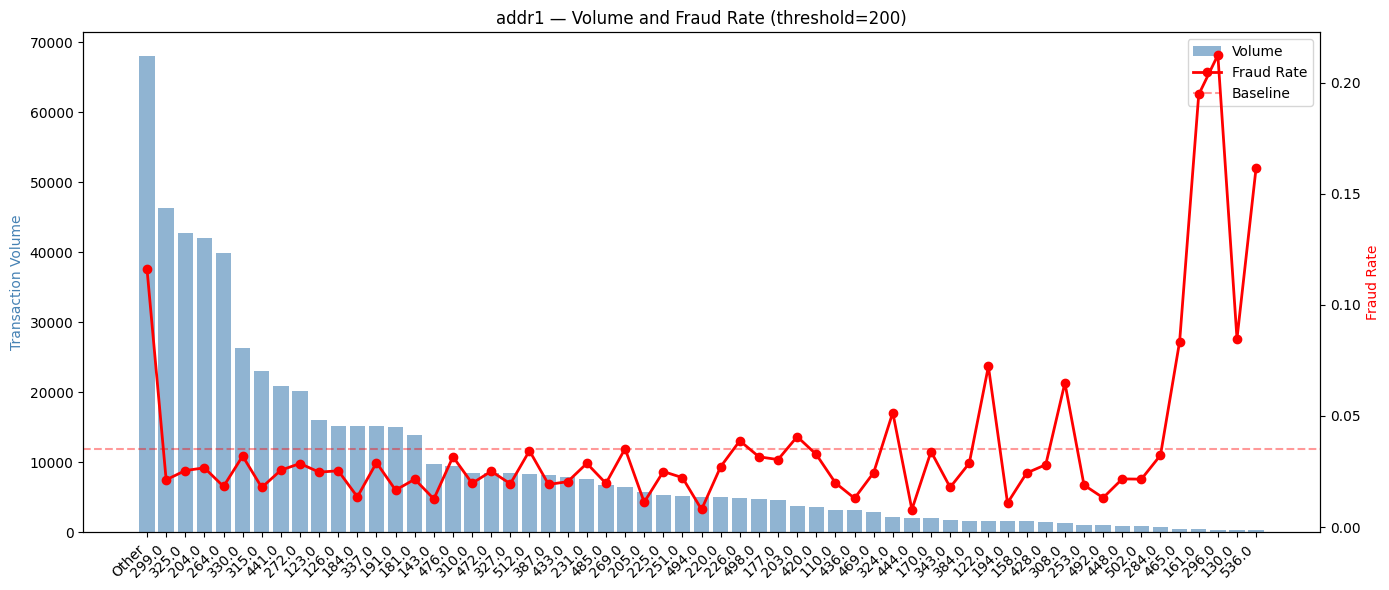

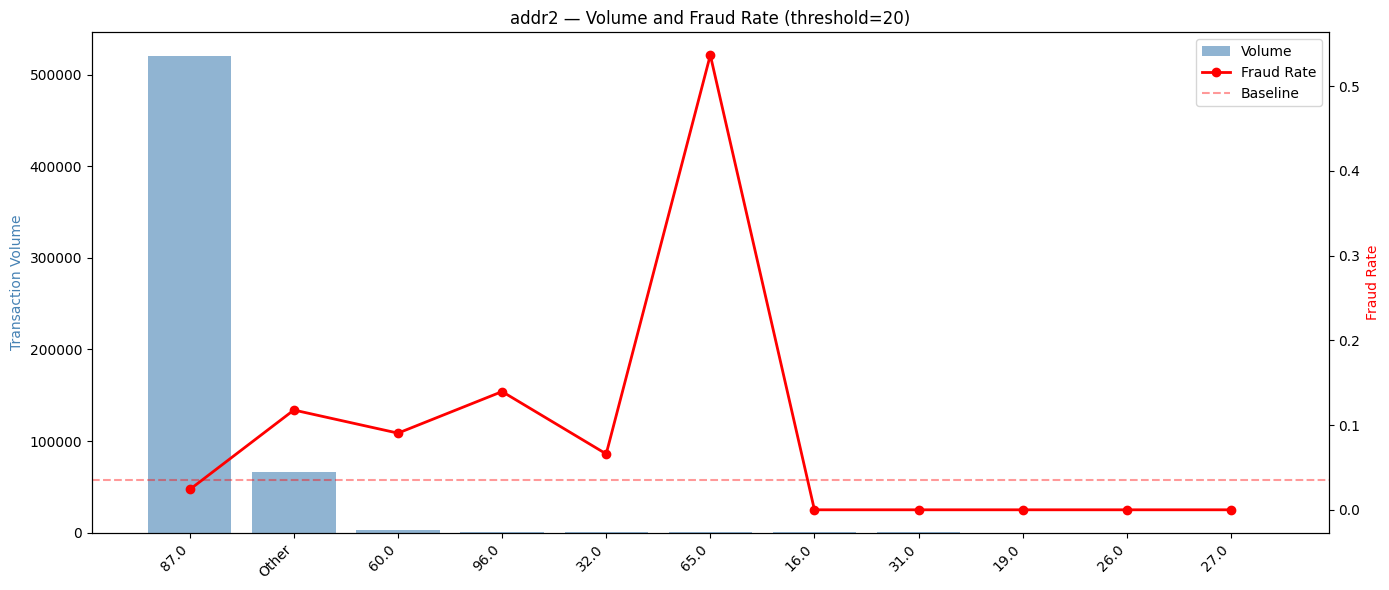

In [34]:
def plot_addr_analysis(df, col, threshold):
    counts = df[col].value_counts()
    
    # Keep high-frequency values, group rest as Other
    keep = counts[counts >= threshold].index
    df[f'{col}_grouped'] = df[col].apply(
        lambda x: x if x in keep else 'Other'
    )
    
    # Build stats
    stats = (
        df.groupby(f'{col}_grouped')['isFraud']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
        .sort_values('volume', ascending=False)
        .reset_index()
    )
    
    # Plot
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()
    
    x = range(len(stats))
    
    ax1.bar(x, stats['volume'], color='steelblue', alpha=0.6, label='Volume')
    ax2.plot(x, stats['fraud_rate'], color='red', marker='o', 
             linewidth=2, label='Fraud Rate')
    ax2.axhline(df['isFraud'].mean(), color='red', linestyle='--', 
                alpha=0.4, label='Baseline')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(
        stats[f'{col}_grouped'].astype(str), 
        rotation=45, ha='right'
    )
    ax1.set_ylabel('Transaction Volume', color='steelblue')
    ax2.set_ylabel('Fraud Rate', color='red')
    ax1.set_title(f'{col} — Volume and Fraud Rate (threshold={threshold})')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return stats

# Run the elbow plot first, then plug in your chosen threshold
addr1_stats = plot_addr_analysis(train, 'addr1', threshold=200)  # adjust after elbow plot
addr2_stats = plot_addr_analysis(train, 'addr2', threshold=20)   # addr2 is low cardinality

In [36]:
print(train[train['addr2'] == 65]['isFraud'].value_counts())

isFraud
1    44
0    38
Name: count, dtype: int64


addr1: 
- Frequency-based grouping is insufficient due to extreme long tail.  
- Target encoding (replacing each zip with its mean fraud rate, computed on training data only) is the appropriate approach.  
- This preserves signal from all zip codes including rare ones without the arbitrary threshold problem.
- This will be implemented in feature engineering.

addr2:  
- 87.0 — ~520,000 transactions, ~3% fraud rate, below baseline
- Other - 60.0, 96.0, 32.0 — all well above baseline (8–15%)
- 65.0 — 52% fraud rate, but just 44 transactions - outlier
- 16.0, 31.0, 19.0, 26.0, 27.0 — all at ~0% fraud rate
- We can create a binary flag - is_dominant_region - 1 if addr2=87, 0 otherwise

## Fraud Rate by Numerical Features

### 1. Transaction Amount Analysis

<Axes: xlabel='TransactionAmt', ylabel='Count'>

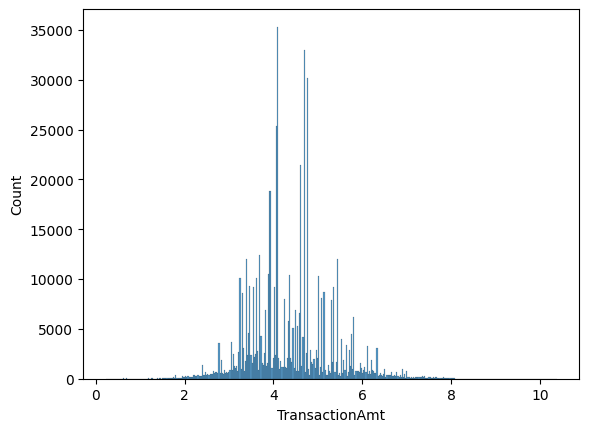

In [21]:
sns.histplot(
    np.log1p(train['TransactionAmt'])
)

<Axes: xlabel='isFraud', ylabel='TransactionAmt'>

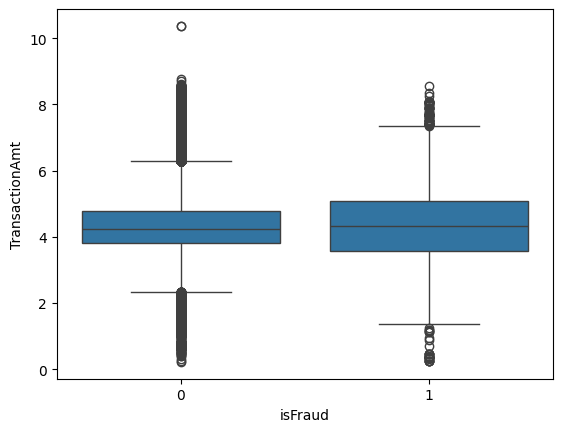

In [22]:
sns.boxplot(
    x='isFraud',
    y=np.log1p(train['TransactionAmt']),
    data=train
)

Analysis:
- The median of fraudulent transactions is slightly more than non-fraudulent transactions, showing the transaction amount is slightly high in case of frauds.
- The transaction amount for fraudulent data is widespread as compared to non-fraudulent (can be seen from the larger IQR).
- We can also see an outlier in non-fraudulent data. This could affect our predictions going forward. 

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15792\1117458036.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['AmtBin'] = pd.qcut(


<Axes: xlabel='AmtBin'>

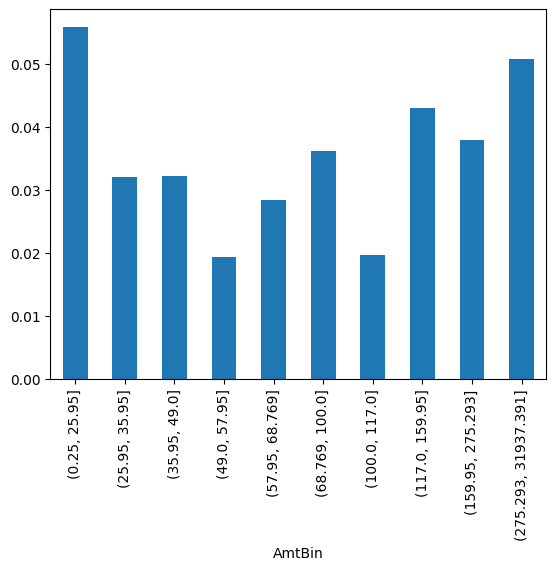

In [23]:
# Create bins
train['AmtBin'] = pd.qcut(
    train['TransactionAmt'],
    q=10,
    duplicates='drop'
)

# Group by the bins
fraud_by_amt = (
    train.groupby('AmtBin')['isFraud']
    .mean()
)

# Plot
fraud_by_amt.plot(kind='bar')

- The smallest transactions have the highest fraud rate. And secondly, the highest transactions have the highest fraud rate. 
- An example of small transactions is when a scammer tests a stolen card if it's active. Once it's confirmed, they mostly go for larger transactions.
The middle ranges appear safest.

In [24]:
train.groupby('isFraud')['TransactionAmt'].agg([
    'count',
    'mean',
    'median',
    'std'
])

,count,mean,median,std
isFraud,,,,
0,569877,134.511665,68.5,239.395078
1,20663,149.244779,75.0,232.212163


In [25]:
# Top 20 largest transactions
train.nlargest(
    20,
    'TransactionAmt'
)[['TransactionAmt','isFraud']]

,TransactionAmt,isFraud
274336,31937.391,0
274339,31937.391,0
296021,6450.970,0
248413,6085.230,0
384603,5543.230,0
275529,5420.000,0
275535,5420.000,0
584767,5366.820,0
303106,5279.950,0
315172,5279.950,0


- It is interesting that most of the top transactions are not fraudulent. There's just one fraud in the top 20 largest transactions. 
- This is probably because larger amounts require an email or mobile verification. 

In [26]:
# Top 20 smallest transactions
train.nsmallest(
    20,
    'TransactionAmt'
)[['TransactionAmt','isFraud']]

,TransactionAmt,isFraud
374299,0.251,0
367961,0.272,0
29976,0.292,1
205370,0.292,1
205382,0.292,1
205865,0.292,1
205872,0.292,1
205393,0.350,1
492354,0.364,0
41932,0.424,1


- On the other hand, we have a lot of transactions with small amounts that are fraudulent.
- Another interesting point is most of the transaction amounts are odd and basically the same.
- These are used to test stolen card numbers on e-commerce sites to see if the card is active, unblocked, and has an available limit before attempting larger purchases.

### 2. Temporal Analysis

In [29]:
train['TransactionDT'].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

In [30]:
train['TransactionDT'].min(), train['TransactionDT'].max()

(np.int64(86400), np.int64(15811131))

In [55]:
(train['TransactionDT'].max() - train['TransactionDT'].min()) / 86400  # The dataset spans roughly 182 days of transactions

np.float64(181.99920138888888)

In [32]:
# Get the transaction days
train['TransactionDay'] = (
    train['TransactionDT'] // 86400
).astype(int)

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15792\3512992190.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionDay'] = (


<Axes: xlabel='TransactionDay'>

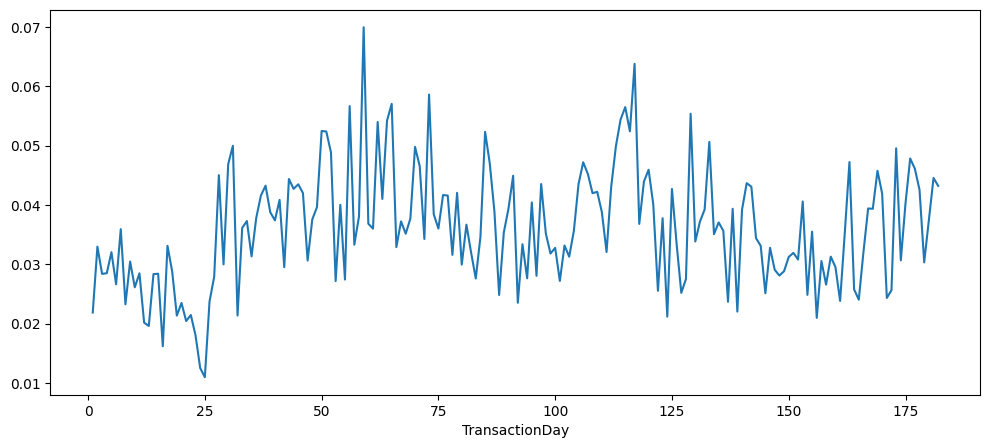

In [33]:
daily_fraud = (
    train.groupby('TransactionDay')['isFraud']
    .mean()
)

daily_fraud.plot(figsize=(12,5))

- There are a few spikes indicating there were few days of increased fraud activity. 
- However, there is no proper trend over time.

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15792\2158502736.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionHour'] = (


<Axes: xlabel='TransactionHour'>

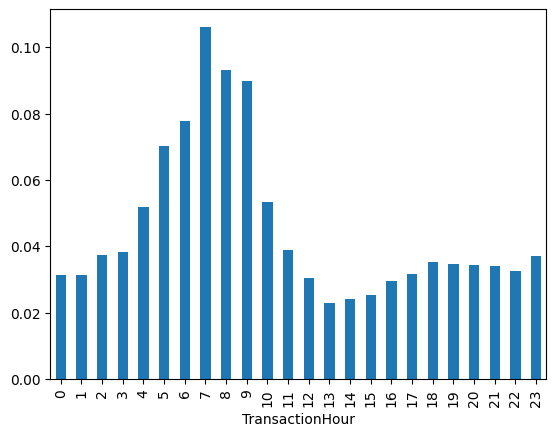

In [34]:
train['TransactionHour'] = (
    (train['TransactionDT'] // 3600) % 24
).astype(int)

hourly_fraud = (
    train.groupby('TransactionHour')['isFraud']
    .mean()
)

hourly_fraud.plot(kind='bar')

In [35]:
hourly_fraud.sort_values(ascending=False)

TransactionHour
7     0.106102
8     0.093014
9     0.089956
6     0.077743
5     0.070302
10    0.053212
4     0.051890
11    0.038816
3     0.038314
2     0.037483
23    0.036997
18    0.035231
19    0.034738
20    0.034273
21    0.034005
22    0.032694
17    0.031530
0     0.031380
1     0.031314
12    0.030439
16    0.029511
15    0.025399
14    0.024216
13    0.022889
Name: isFraud, dtype: float64

- Hours 5 to 9 have the highest fraud activity, peak at hour 6, showing time of the day matters.
- However, we do not have the exact hours and timezone as we have just calculated this from timedelta. So the actual hours could be different, most likely night hours. 

In [36]:
train.groupby('TransactionHour').size()

TransactionHour
0     37795
1     32797
2     26732
3     20802
4     14839
5      9701
6      6007
7      3704
8      2591
9      2479
10     3627
11     6827
12    12451
13    20315
14    28328
15    33859
16    38698
17    40723
18    41639
19    42115
20    41782
21    41641
22    41139
23    39949
dtype: int64

In [37]:
hourly_stats = (
    train.groupby('TransactionHour')['isFraud']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'transactions',
        'sum': 'frauds',
        'mean': 'fraud_rate'
    })
)

hourly_stats.sort_values(
    'fraud_rate',
    ascending=False
)

,transactions,frauds,fraud_rate
TransactionHour,,,
7,3704,393,0.106102
8,2591,241,0.093014
9,2479,223,0.089956
6,6007,467,0.077743
5,9701,682,0.070302
10,3627,193,0.053212
4,14839,770,0.051890
11,6827,265,0.038816
3,20802,797,0.038314


- We can trust the fraud rates as we have quite a few transactions during the peak hours. If we had like 10 transactions with 5 frauds, the 50% fraud rate wouldn't have made sense. But it looks useful.
- The highest fraud hours are also the lowest volume hours. This could possibly mean more fraudsters are active when normal customers are inactive.
- TransactionHour looks like a good feature for predictions.

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15792\186075757.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionWeek'] = (


<Axes: xlabel='TransactionWeek'>

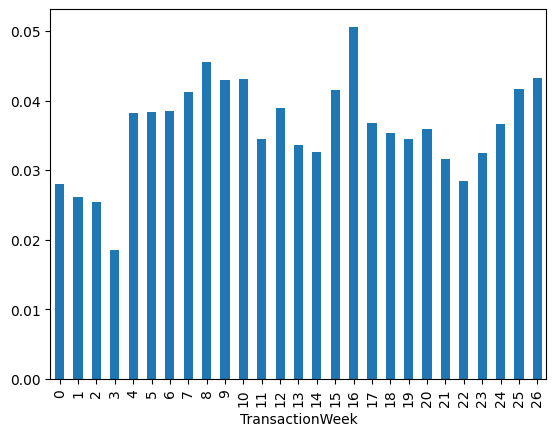

In [38]:
train['TransactionWeek'] = (
    train['TransactionDT'] // (86400 * 7)
).astype(int)

weekly_fraud = (
    train.groupby('TransactionWeek')['isFraud']
    .mean()
)

weekly_fraud.plot(kind='bar')

- There are no weekly patterns visible. 
- Some weeks show increased fraud activity, but there is no clear increase or decrease over the weeks.

### 3. V-Feature Analysis

In [18]:
v_feats = train.loc[:,'V1':'V339'].copy()
v_feats['isFraud'] = train['isFraud']
v_feats.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V331,V332,V333,V334,V335,V336,V337,V338,V339,isFraud
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [19]:
# Correlation of each V feature with target
v_target_corr = (
    v_feats.corr()['isFraud']
    .drop('isFraud')
    .sort_values(key=abs, ascending=False)
)

print("Top 20 V features correlated with fraud:")
print(v_target_corr.head(20))


Top 20 V features correlated with fraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64


C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_16496\1848603455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_v.values, y=top_v.index, palette=colors)


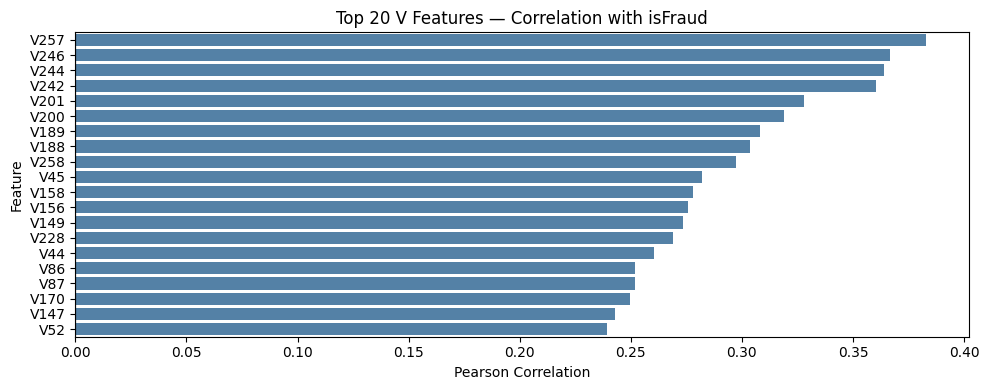

In [29]:
top_v = v_target_corr.head(20)

plt.figure(figsize=(10, 4))
colors = ['red' if x < 0 else 'steelblue' for x in top_v.values]
sns.barplot(x=top_v.values, y=top_v.index, palette=colors)

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 V Features — Correlation with isFraud')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

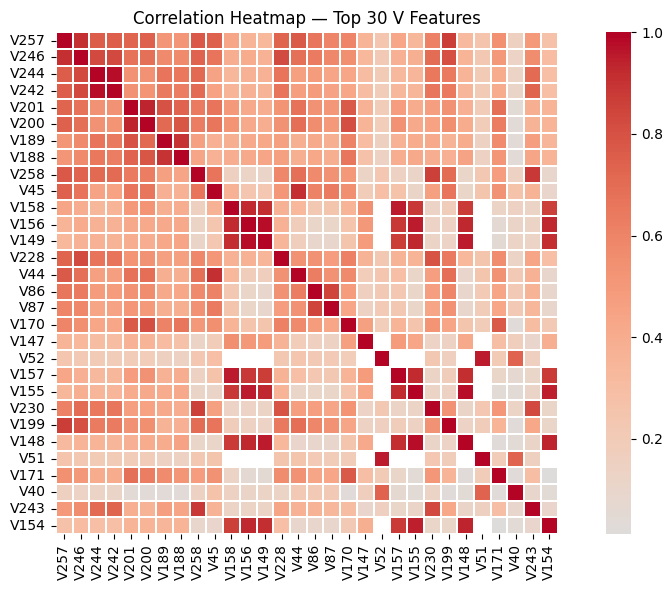

In [28]:
top_v_cols = v_target_corr.head(30).index.tolist()

plt.figure(figsize=(10, 6))
corr_matrix = v_feats[top_v_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot=False,       # too many features to annotate legibly
    square=True
)

plt.title('Correlation Heatmap — Top 30 V Features')
plt.tight_layout()
plt.show()

The heatmap reveals clear cluster structure in the V features — groups of highly inter-correlated variables likely representing the same underlying signal. In feature engineering, we can select one representative per cluster or create aggregations rather than using all 339 features. This reduces multicollinearity and dimensionality.

Some distinct clusters observed:  
{V257, V246, V244, V242}  
{V201, V200, V189, V188}  
{V158, V156, V149}  
{V86, V87}  
{V157, V155, V148}  
{V52, V147, V170}  

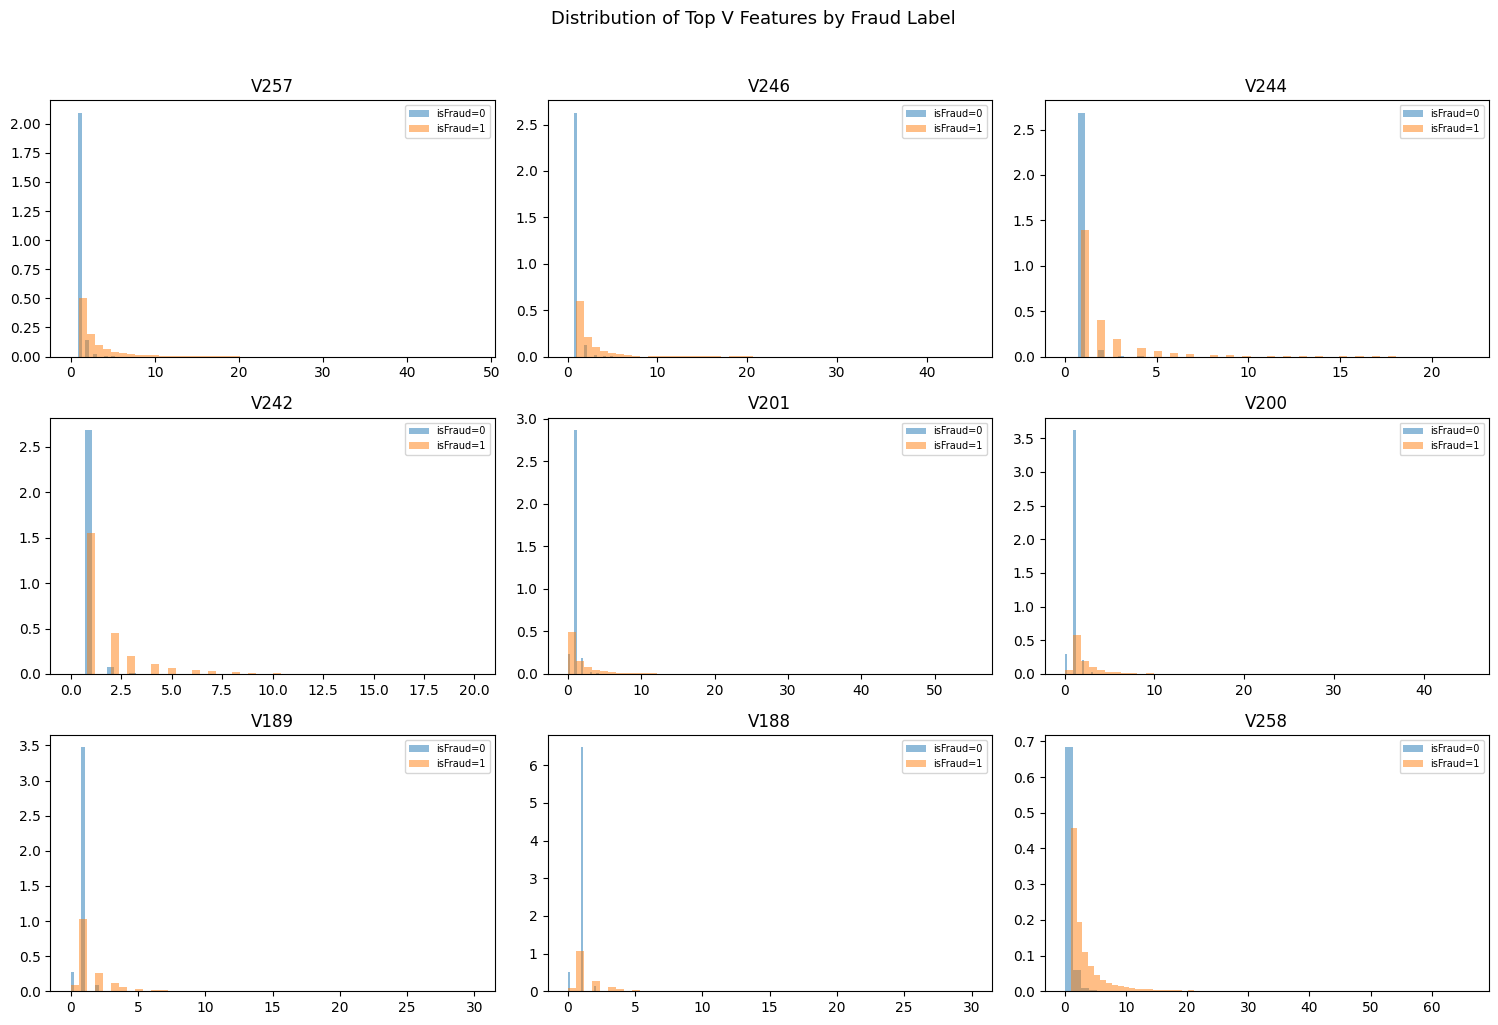

In [22]:
# Pick top 9 by absolute correlation for a clean 3x3 grid
top9 = v_target_corr.head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top9):
    for label, grp in v_feats.groupby('isFraud'):
        axes[i].hist(
            grp[col].dropna(),
            bins=50,
            alpha=0.5,
            density=True,
            label=f'isFraud={label}'
        )
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Top V Features by Fraud Label', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

All top V features show a heavy right-skewed distribution. The key pattern is:
- Non-fraud (blue): extremely concentrated at low values (near 0-1), very sharp spike
- Fraud (orange): flatter, more spread out, with a longer right tail

This means fraud transactions tend to have HIGHER values on these V features.

### 4. C-Feature Analysis

In [5]:
## C Feature Analysis

c_cols = [col for col in train.columns if col.startswith('C')]
print(f"C features: {c_cols}")

C features: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


In [6]:
# Fraud rate and distribution stats per C feature
c_analysis = []

for col in c_cols:
    c_analysis.append({
        'feature': col,
        'missing_pct': train[col].isnull().mean() * 100,
        'mean_fraud': train.loc[train['isFraud'] == 1, col].mean(),
        'mean_legit': train.loc[train['isFraud'] == 0, col].mean(),
        'ratio': train.loc[train['isFraud'] == 1, col].mean() / train.loc[train['isFraud'] == 0, col].mean(),
        'corr_with_target': train[col].corr(train['isFraud'])
    })

c_analysis_df = pd.DataFrame(c_analysis).sort_values('ratio', ascending=False)
print(c_analysis_df)

   feature  missing_pct  mean_fraud  mean_legit     ratio  corr_with_target
11     C12          0.0   18.597541    3.549703  5.239183          0.031905
6       C7          0.0   11.977157    2.517484  4.757591          0.028160
7       C8          0.0   21.242608    4.560881  4.657567          0.032139
9      C10          0.0   19.493926    4.723526  4.126986          0.028396
3       C4          0.0   15.077336    3.693878  4.081710          0.030382
1       C2          0.0   45.509413   14.173283  3.210930          0.037229
0       C1          0.0   35.535740   13.314952  2.668860          0.030570
10     C11          0.0   23.857475    9.747825  2.447467          0.027484
5       C6          0.0   16.923148    8.786377  1.926067          0.020909
13     C14          0.0   10.356047    8.220491  1.259784          0.007921
12     C13          0.0   24.967768   32.814474  0.760877         -0.011146
8       C9          0.0    1.703964    4.580904  0.371971         -0.031703
4       C5  

- Ratio = mean_fraud / mean_legit  
- Ratio > 1 → fraudsters have higher counts → higher count = more suspicious
- Ratio < 1 → fraudsters have lower counts → higher count = safer
- Note that there are no missing values in case of C features.

- High Ratio, Positive Correlation - C12, C7, C8, C10, C4 - Fraudulent transactions have 4–5x higher counts than legitimate ones.
- Moderate Ratio - C2, C1, C11, C6, C14 - Fraud transactions are slightly more than legitimate transactions.
- Low Ratio, Negative Correlation - Low rates of frauds as compared to legitimate transactions.

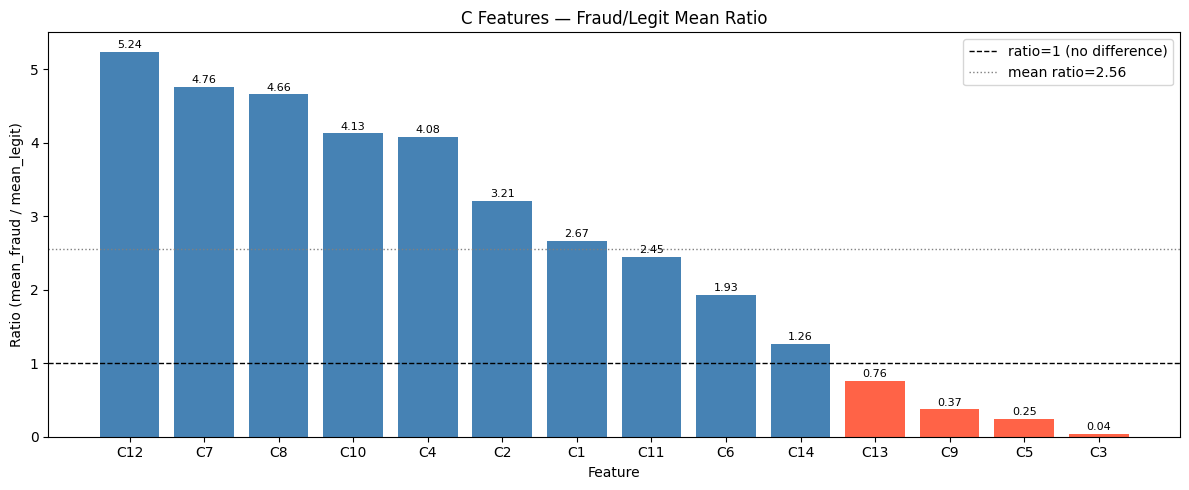

In [8]:
c_analysis_df['color'] = c_analysis_df['ratio'].apply(
    lambda x: 'steelblue' if x >= 1 else 'tomato'
)

plt.figure(figsize=(12, 5))
bars = plt.bar(
    c_analysis_df['feature'], 
    c_analysis_df['ratio'],
    color=c_analysis_df['color']
)

plt.axhline(1, color='black', linewidth=1, linestyle='--', label='ratio=1 (no difference)')
plt.axhline(c_analysis_df['ratio'].mean(), color='grey', linewidth=1, 
            linestyle=':', label=f'mean ratio={c_analysis_df["ratio"].mean():.2f}')

# Annotate each bar with the ratio value
for bar, (_, row) in zip(bars, c_analysis_df.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{row["ratio"]:.2f}', ha='center', fontsize=8)

plt.title('C Features — Fraud/Legit Mean Ratio')
plt.xlabel('Feature')
plt.ylabel('Ratio (mean_fraud / mean_legit)')
plt.legend()
plt.tight_layout()
plt.show()

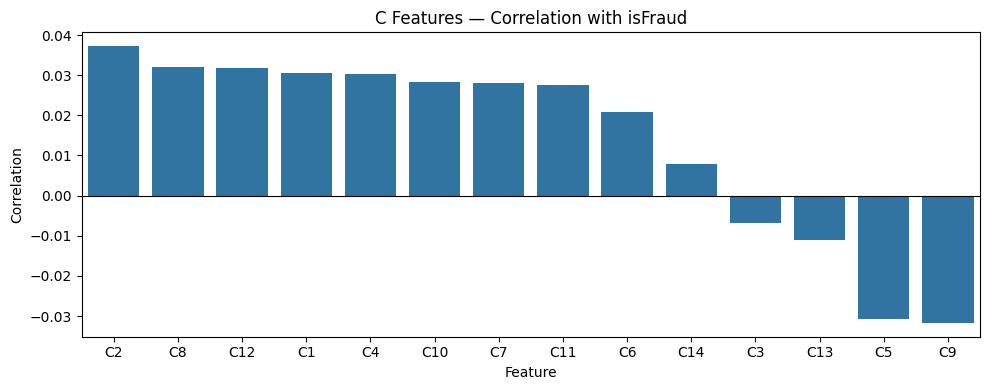

In [9]:
# Correlation of C features with target
c_corr = train[c_cols].corrwith(train['isFraud']).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=c_corr.index, y=c_corr.values)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('C Features — Correlation with isFraud')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

- The correlations are all very small (max ~0.037). 
- This is expected - Pearson correlation only captures linear relationships.
- We can observe the same correlations as above:  
Positive correlation: C2, C1, C4, C6, C7, C8, C10, C11, C12, C14  
Negative correlation: C3, C5, C9, C13  

### 5. D-Feature Analysis

These are timedelta features, such as days between transactions, etc.  
As we have seen above, these columns have too many missing values. So we need to consider that while analysing these features.

In [25]:
## D Feature Analysis

d_cols = [col for col in train.columns if (col.startswith('D')) and (col not in ['DeviceType', 'DeviceInfo'])]
print(f"D features: {d_cols}")

# 1. Missingness summary — already informative in itself
d_missing_fraud = []

for col in d_cols:
    indicator = train[col].isnull().astype(int)
    fraud_when_missing = train.loc[indicator == 1, 'isFraud'].mean()
    fraud_when_present = train.loc[indicator == 0, 'isFraud'].mean()
    
    d_missing_fraud.append({
        'feature': col,
        'missing_pct': train[col].isnull().mean() * 100,
        'fraud_rate_when_missing': fraud_when_missing,
        'fraud_rate_when_present': fraud_when_present,
        'difference': fraud_when_missing - fraud_when_present
    })

d_missing_df = pd.DataFrame(d_missing_fraud).sort_values('difference', ascending=False)
d_missing_df

D features: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']


,feature,missing_pct,fraud_rate_when_missing,fraud_rate_when_present,difference
10,D11,47.293494,0.052122,0.019617,0.032505
1,D2,47.549192,0.045560,0.025408,0.020151
9,D10,12.873302,0.051117,0.032607,0.018510
14,D15,15.090087,0.047984,0.032681,0.015303
2,D3,44.514851,0.042012,0.029356,0.012655
3,D4,28.604667,0.036088,0.034550,0.001537
0,D1,0.214888,0.036249,0.034987,0.001262
4,D5,52.467403,0.031574,0.038760,-0.007186
8,D9,87.312290,0.024895,0.104463,-0.079568
7,D8,87.312290,0.024895,0.104463,-0.079568


In [11]:
print(train[['D8','D9']].corr())
print((train['D8'] == train['D9']).value_counts())

          D8        D9
D8  1.000000  0.066085
D9  0.066085  1.000000
False    571697
True      18843
Name: count, dtype: int64


- For columns, D7, D12, D14, D13, D6, D8, D9, D5 -> Negative difference -> Fraud rate is higher when then the value is present as opposed to when missing -> Shows this value is mostly generated when the transaction is fraudulent.
- D7, D12, D14, D13, D6, D8, D9 -> High difference between the two. 
- Columns D8 and D9 -> Identical missing percentage and identical fraud rates when missing v/s present -> However, correlation analysis shows they're different features, not duplicates. 
- Columns D11, D2, D10, D15, D3, D4, D1 -> Positive difference -> Fraud rate is higher when the value is missing.
- D1 - Lowest percentage of missing values.
- D4 and D1 - Very low difference between fraud rates when value is present vs missing. 

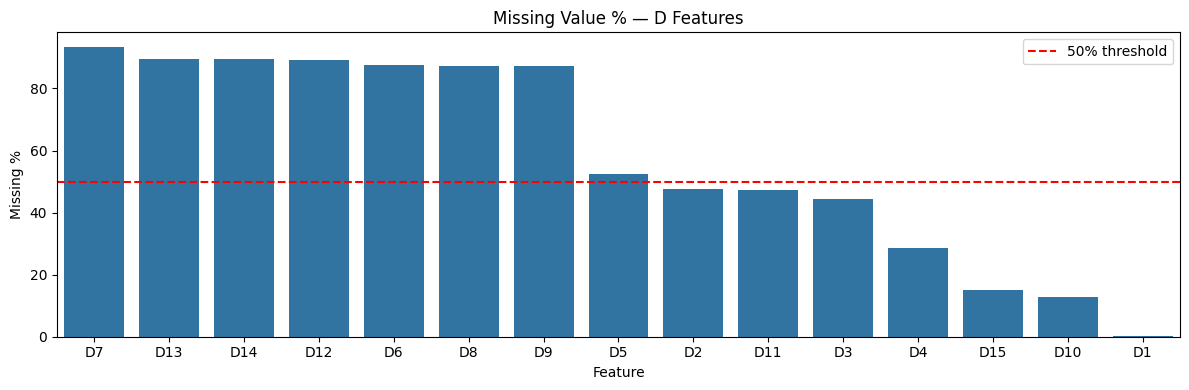

In [25]:
# For D features, missing % matters a lot — first visualise it
d_missing = train[d_cols].isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 4))
sns.barplot(x=d_missing.index, y=d_missing.values)
plt.title('Missing Value % — D Features')
plt.ylabel('Missing %')
plt.xlabel('Feature')
plt.axhline(50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_25104\3345585267.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=d_corr.index, y=d_corr.values, palette=colors)


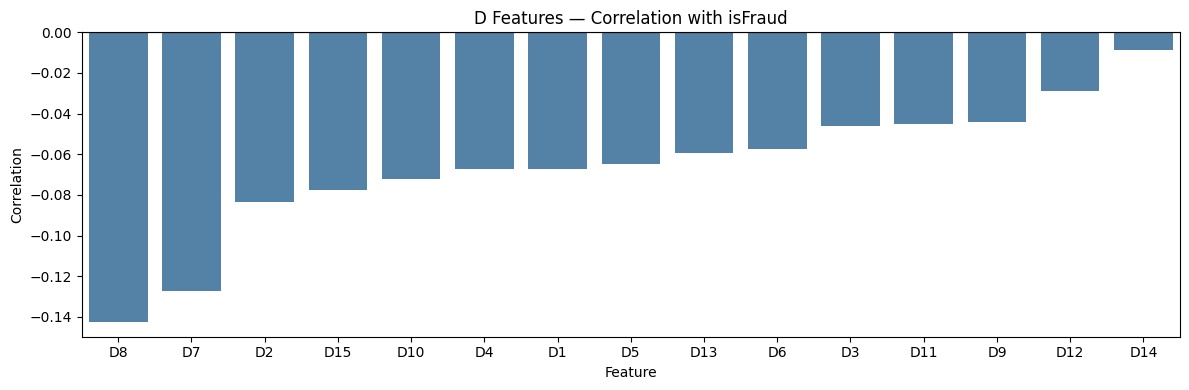

In [27]:
# D feature correlations with target
d_corr = train[d_cols].corrwith(train['isFraud']).sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 4))
colors = ['steelblue' if x < 0 else 'red' for x in d_corr.values]
# colors = ['steelblue']
sns.barplot(x=d_corr.index, y=d_corr.values, palette=colors)
# sns.barplot(x=d_corr.index, y=d_corr.values, hue=x, legend=False)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('D Features — Correlation with isFraud')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

- D8 has the highest negative correlation with the target variable, with D7 following closely.
- D14 does not seem to be correlated closely to the target.
- However, Pearson's correlation coefficient only tells us the linear relationships between variables, we might find more going forward.

### 6. id_1 to id_11 (Numerical id features)

In [30]:
## Numerical ID Feature Analysis

num_id_cols = ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11']

# 1. Missingness summary — already informative in itself
id_missing_fraud = []

for col in num_id_cols:
    indicator = train[col].isnull().astype(int)
    fraud_when_missing = train.loc[indicator == 1, 'isFraud'].mean()
    fraud_when_present = train.loc[indicator == 0, 'isFraud'].mean()
    
    id_missing_fraud.append({
        'feature': col,
        'missing_pct': train[col].isnull().mean() * 100,
        'fraud_rate_when_missing': fraud_when_missing,
        'fraud_rate_when_present': fraud_when_present,
        'difference': fraud_when_missing - fraud_when_present
    })

id_missing_df = pd.DataFrame(id_missing_fraud).sort_values('missing_pct', ascending=False)
id_missing_df

,feature,missing_pct,fraud_rate_when_missing,fraud_rate_when_present,difference
6,id_07,99.127070,0.034570,0.082638,-0.048068
7,id_08,99.127070,0.034570,0.082638,-0.048068
2,id_03,88.768923,0.025850,0.107231,-0.081381
3,id_04,88.768923,0.025850,0.107231,-0.081381
8,id_09,87.312290,0.024895,0.104463,-0.079568
9,id_10,87.312290,0.024895,0.104463,-0.079568
4,id_05,76.823755,0.021339,0.080240,-0.058901
5,id_06,76.823755,0.021339,0.080240,-0.058901
1,id_02,76.145223,0.020995,0.079661,-0.058665
10,id_11,76.127273,0.021009,0.079573,-0.058563


In [12]:
pairs = [('id_07','id_08'), ('id_03','id_04'), ('id_09','id_10'), ('id_05','id_06')]

for a, b in pairs:
    corr = train[a].corr(train[b])
    identical = (train[a] == train[b]).mean()
    print(f"{a}/{b}: correlation={corr:.4f} | identical values={identical:.4f}")

id_07/id_08: correlation=-0.0941 | identical values=0.0004
id_03/id_04: correlation=0.3422 | identical values=0.1077
id_09/id_10: correlation=0.3160 | identical values=0.1174
id_05/id_06: correlation=-0.2916 | identical values=0.1337


- All the ID features have a higher fraud rate when the values are present as compared to when they're missing.
- These feature pairs share identical missing percentages: id_07/id_08, id_03/id_04, id_09/id_10, id_05/id_06. However, upon checking further, they're not closely correlated. So we need insights from all of them.
- id_03  and id_04 have the highest difference between fraud rates when value is present vs missing. 

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_25104\2452906293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=id_corr.index, y=id_corr.values, palette=colors)


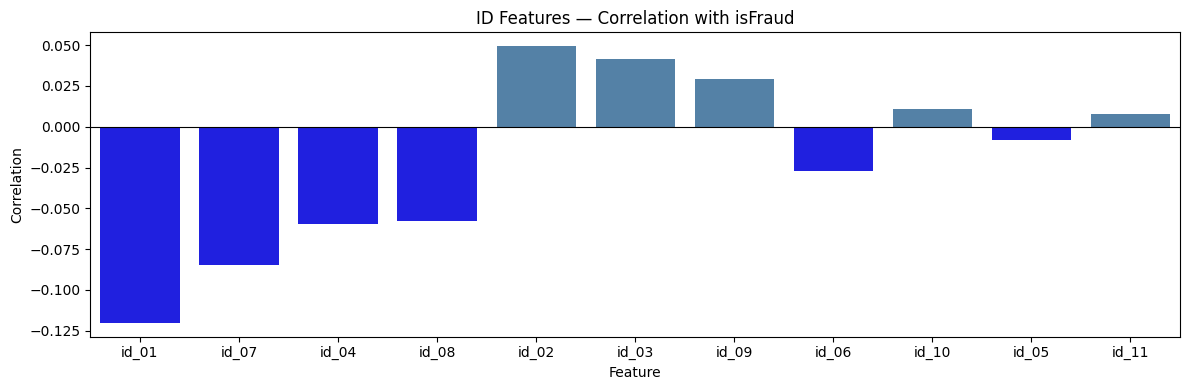

In [36]:
# ID feature correlations with target

num_id_cols = ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11']

id_corr = train[num_id_cols].corrwith(train['isFraud']).sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 4))
colors = ['blue' if x < 0 else 'steelblue' for x in id_corr.values]
sns.barplot(x=id_corr.index, y=id_corr.values, palette=colors)
# sns.barplot(x=d_corr.index, y=d_corr.values, hue=x, legend=False)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('ID Features — Correlation with isFraud')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

- id_01 has the highest correlation with the target and also the lowest missing percentage. 
- id_07 has the second highest correlation but with 99% missing values.
- id_02, id_03, id_09 and id_10 are the only ID features with a positive correlation with the target variable.

### 7. dist1, dist2

In [18]:
# Does missing dist1 carry fraud signal?
print("Fraud rate when dist1 missing:", train.loc[train['dist1'].isnull(), 'isFraud'].mean())
print("Fraud rate when dist1 present:", train.loc[train['dist1'].notnull(), 'isFraud'].mean())

# Does missing dist1 carry fraud signal?
print("Fraud rate when dist2 missing:", train.loc[train['dist2'].isnull(), 'isFraud'].mean())
print("Fraud rate when dist2 present:", train.loc[train['dist2'].notnull(), 'isFraud'].mean())

Fraud rate when dist1 missing: 0.04515841497029276
Fraud rate when dist1 present: 0.019956435793158152
Fraud rate when dist2 missing: 0.030623262610935176
Fraud rate when dist2 present: 0.09915751986605363


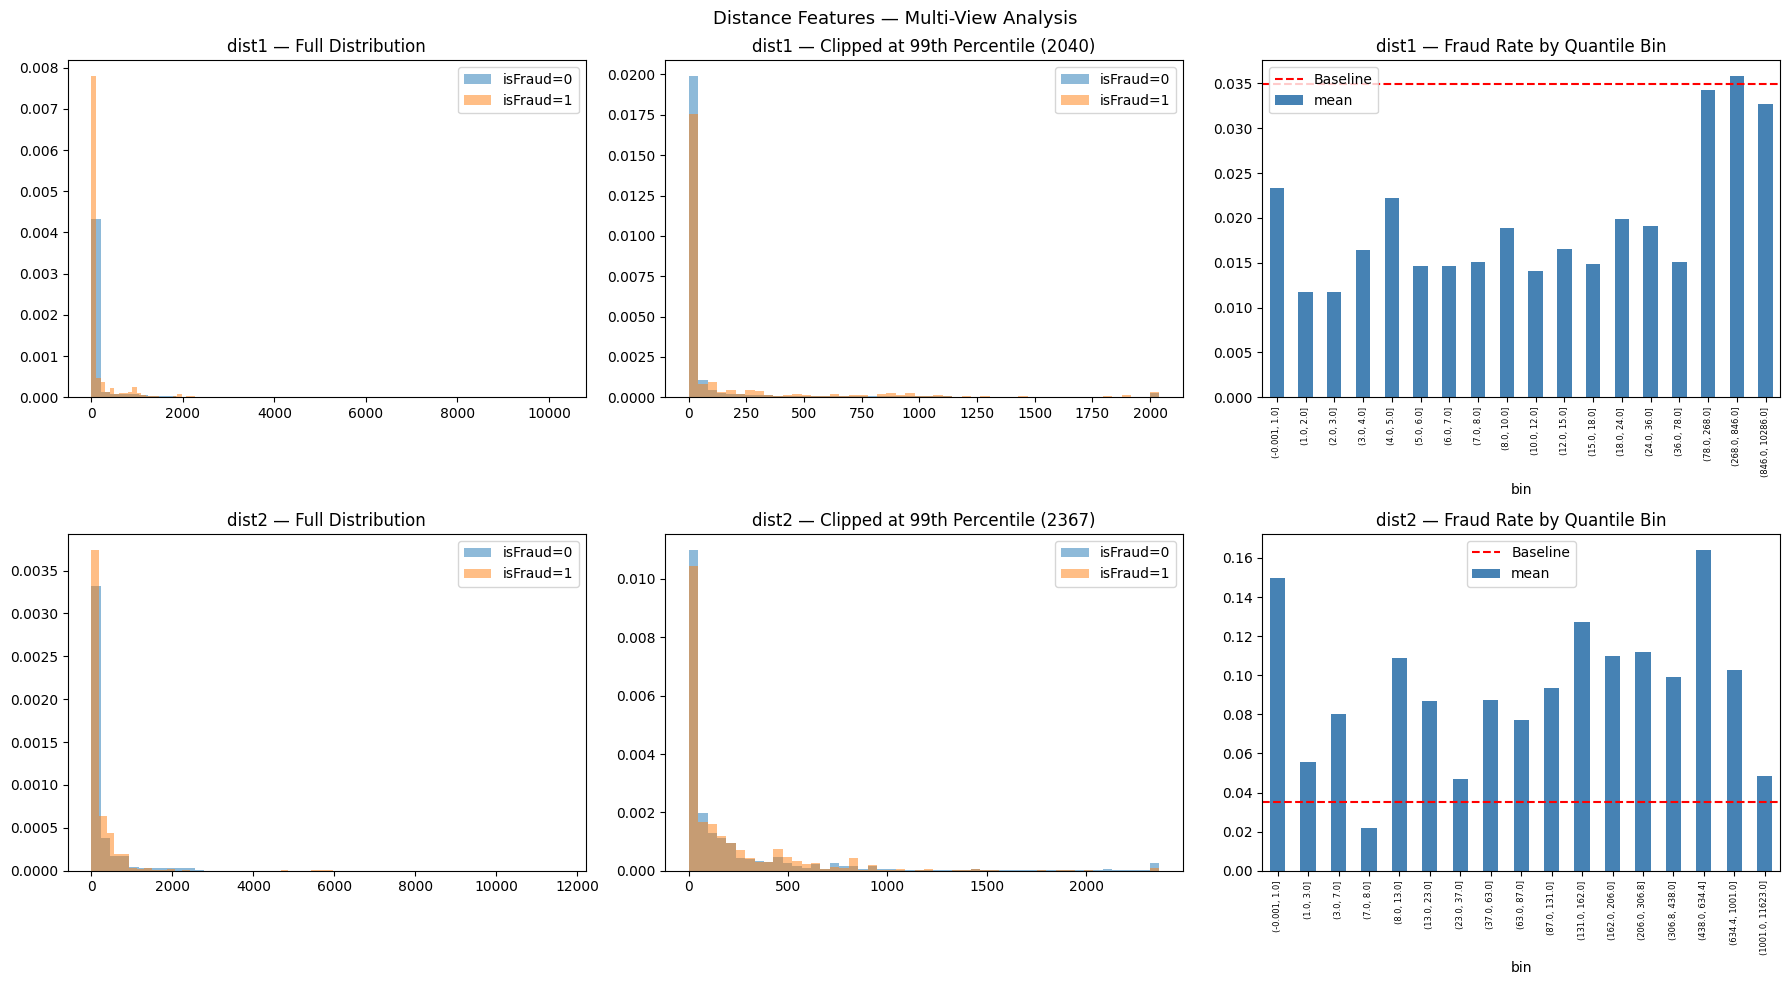

In [19]:
dist_cols = ['dist1', 'dist2']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, col in enumerate(dist_cols):
    data = train[[col, 'isFraud']].dropna()
    
    # Plot 1: Full distribution (what you have now — shows the zero spike)
    for label, grp in data.groupby('isFraud'):
        axes[row, 0].hist(grp[col], bins=50, alpha=0.5, 
                          density=True, label=f'isFraud={label}')
    axes[row, 0].set_title(f'{col} — Full Distribution')
    axes[row, 0].legend()
    
    # Plot 2: Clipped at 99th percentile (removes extreme outliers, 
    # shows the bulk of the distribution more clearly)
    p99 = data[col].quantile(0.99)
    for label, grp in data.groupby('isFraud'):
        axes[row, 1].hist(grp[col].clip(upper=p99), bins=50, alpha=0.5,
                          density=True, label=f'isFraud={label}')
    axes[row, 1].set_title(f'{col} — Clipped at 99th Percentile ({p99:.0f})')
    axes[row, 1].legend()
    
    # Plot 3: Binned fraud rate (most informative for continuous features)
    data['bin'] = pd.qcut(data[col], q=20, duplicates='drop')
    binned = data.groupby('bin')['isFraud'].agg(['mean', 'count'])
    binned['mean'].plot(kind='bar', ax=axes[row, 2], color='steelblue')
    axes[row, 2].axhline(train['isFraud'].mean(), color='red', 
                         linestyle='--', label='Baseline')
    axes[row, 2].set_title(f'{col} — Fraud Rate by Quantile Bin')
    axes[row, 2].tick_params(axis='x', labelsize=6)
    axes[row, 2].legend()

plt.suptitle('Distance Features — Multi-View Analysis', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
dist_cols = ['dist1', 'dist2']

dist_corr = train[dist_cols].corrwith(train['isFraud']).sort_values(key=abs, ascending=False)
dist_corr

dist1    0.021522
dist2   -0.019054
dtype: float64

dist 1
- Fraud rate is high at very low distance, low at the middle and again high at the higher distances. 
- Distributions of fraud vs legitimate overlap almost completely

dist 2
- There is a fraud spike at distances close to 0. 
- Strong non-linear signal despite near-zero overall correlation

Pearson correlation is low for both variables. We'll go for missing indicator and take logs of these two columns in feature engineering. 

# EDA Summary and Conclusions

### Class Imbalance
Only 3.5% of transactions are fraudulent (20,663 out of 590,540).
Must be addressed at multiple stages:
- Training: scale_pos_weight parameter in LightGBM/XGBoost, or class weights
- Evaluation: AUC-ROC and Precision-Recall AUC are the right metrics.
  Accuracy is misleading — predicting all legitimate achieves 96.5%.

---

### Feature Families

#### Categorical Features
ProductCD, card1–card6, addr1, addr2, P_emaildomain, R_emaildomain, M1–M9, id_12–id_38, DeviceType, DeviceInfo

**ProductCD** — 5 categories, no missing values. Category C has the highest fraud rate (~12%) despite low volume. W dominates volume with the lowest fraud rate (~2%). Clean, low-cardinality feature.

**card1–card6** — Payment card information. card1 (13,553 unique values) and card2 (500) are high-cardinality identifiers with specific values showing 40–52% fraud rates — compromised cards reused across transactions. card3 and card5 are moderate-cardinality type features with a few high-risk values (card3=185 at 13.1% with 56k transactions). card4 (network) and card6 (type) are low-cardinality — credit cards and Discover show elevated fraud rates.

**addr1, addr2** — Billing address features. 
addr1 has extreme long-tail distribution (~330 zip codes) where frequency-based grouping fails. 
addr2 is dominated by one value (code 87, ~87% of transactions) with below-baseline fraud rate; all other codes show 8–52% fraud rates.

**P/R_emaildomain** — Purchaser and recipient email domains. 
R_emaildomain consistently shows higher fraud rates than P_emaildomain for the same domain, suggesting the recipient field is more often under fraudster control. mail.com is the highest-risk domain in both fields. Foreign TLD domains (.es, .fr, .mx) are elevated.

**M1–M9** — Match features (identity verification results). Consistent fraud rate pattern: Missing > F > T across all features. Fraudsters bypass verification entirely rather than failing checks — explaining why Missing outranks even False matches. M4 uses a different encoding (M0/M1/M2 confidence levels) and has M4=M2 as its highest-fraud value at 11.4%.

**id_12–id_38** — Categorical identity features (device/network signals). 
Missing rate is ~2.1% universally — structural absence (no identity record collected), not informative. This is below baseline, opposite to M feature missingness. id_23 anonymous proxy (13.7%) and id_32 screen depth=0 (~50%) are the strongest signals. id_37 is anomalous — T > F, opposite to all other T/F features.

**DeviceType, DeviceInfo** — Device information. Mobile (~10%) is riskier than desktop (~6%). Android device families are 3–5x above baseline;  MacOS is below baseline. SM-A300H Build/LRX22G has 83% fraud rate — likely a targeted or compromised device model. Missing DeviceInfo (80% of data) shows 2.5% fraud — structural low-risk absence.

---

#### Numerical Features
TransactionAmt, TransactionDT (→ derived), dist1, dist2, C1–C14, D1–D15, V1–V339, id_01–id_11

**TransactionAmt** — Heavily right-skewed. U-shaped fraud rate: smallest and largest transactions are highest risk. Small identical amounts (~$1) cluster in fraud — card-testing pattern. log1p transformation needed.

**TransactionDT** — Seconds-based timedelta, not a real timestamp. Dataset spans ~182 days. Hours 5–9 show peak fraud rates coinciding with lowest transaction volume — fraudsters more active when legitimate customers are inactive. Derived into TransactionDay, TransactionHour, TransactionWeek.

**dist1, dist2** — Distance features. Both weakly correlated linearly but reveal non-linear signals through binned analysis. dist1 shows a U-shaped pattern (low and high distances both elevated). dist2 has a spike at distance≈0 (~15% fraud). Pearson correlation near zero for both because the non-linear shape cancels in a linear measure.

**C1–C14** — Count features, no missing values. Two groups: high-ratio (C12, C8, C7 at 4–5x fraud/legit mean) where fraudsters inflate counts by reusing credentials, and low-ratio (C3, C5, C9) where fraudsters score near-zero on legitimacy-confirming counts. All heavily right-skewed.

**D1–D15** — Timedelta features. All negatively correlated with fraud — longer elapsed time = lower risk, fraudsters act quickly. Two missingness regimes: high-missing columns (D6–D9, D12–D14) where fraud rate is higher when present; moderate-missing columns (D2, D11, D10) where fraud rate is higher when absent. D8 and D9 share identical missing rates but are  independent features (correlation = 0.066).

**V1–V339** — Vesta-engineered features. Top features positively correlated with fraud (V257 at 0.38). Clear cluster structure — 6+ groups of highly inter-correlated features representing the same underlying signal at different time windows. Fraud transactions show higher V values — consistent with velocity count interpretation.

**id_01–id_11** — Numerical identity features. All show higher fraud rates when present than when missing — presence signals a higher-risk transaction type. id_01 is the strongest signal(-0.12 correlation) with the lowest missing rate (75.6%). Five feature pairs share identical missing rates but are verified as independent signals.

---

### Feature Engineering Plan

Note: All transformations applied in the feature engineering notebook. All encoders fitted on train split only and applied to validation split to prevent data leakage.

| Feature | Action |
|---|---|
| ProductCD | One-hot encode (5 categories, 0% missing) |
| card1, card2 | Target encode + velocity aggregations (transaction count, mean/std amount per card) |
| card3, card5 | Target encode |
| card4, card6 | One-hot encode (fill NaN with 'Missing' first) |
| addr1 | Target encode (frequency grouping fails — long tail too large) |
| addr2 | Binary flag: is_dominant_region (1 if addr2=87, 0 otherwise)|
| P/R_emaildomain | Group into families (Google/Microsoft/Yahoo/Apple/Foreign/Other), one-hot encode, fill NaN with 'Missing' |
| M1–M3, M5–M9 | Fill NaN with 'Missing', one-hot encode (T/F/Missing → separate binary columns) |
| M4 | Fill NaN with 'Missing', one-hot encode separately (M0/M1/M2/Missing) |
| id_12–id_38 | Fill NaN with 'Missing', binary encode per feature (each feature independently based on its own fraud rate ordering — id_37 is anomalous) |
| DeviceType | One-hot encode (fill NaN with 'Missing' first) |
| DeviceInfo | Use DeviceInfo_grouped categories, replace NaN with 'Missing' one-hot encode |
| TransactionAmt | log1p transformation |
| TransactionDT | Derive features into TransactionDay, TransactionHour, TransactionWeek |
| C1–C14 | log1p transformation (heavily right-skewed count features) |
| D1–D15 | Retain raw values (tree models handle NaN natively); create missing indicators for all features where missingness-fraud difference > 0.01 |
| dist1 | log1p transformation + create missing indicator (59.7% missing, fraud signal confirmed) |
| dist2 | Retain value + missing indicator already created (93.6% missing) |
| id_01–id_11 | Create missing indicators for all 11 (all show fraud_when_present > fraud_when_missing regardless of missing rate); retain raw values |
| V1–V339 | Greedy correlation-based selection: sort by target correlation, iteratively add features only if inter-correlation with already-selected features < 0.85. Reduces ~339 to ~50 features without losing signal. Do NOT use PCA — destroys interpretability critical for fraud detection |

**Velocity aggregation features (new, using card1 as groupby key):**
- card1_transaction_count
- card1_mean_transaction_amount
- card1_std_transaction_amount
- Repeat for card2

**Note:** Grouped columns created during EDA (addr1_grouped, addr2_grouped, DeviceInfo_grouped) were for visualisation only. All transformations will be applied cleanly from the raw data in the feature engineering notebook.

**Train/validation split:** 80/20 time-based split, applied before any feature engineering to prevent data leakage.